<a href="https://colab.research.google.com/github/hd-nguyen/PetriNet2Vec/blob/main/PetriNet2VectorAndEmbeddingsClusters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!sudo apt install libopenblas-dev
!pip install gensim
!pip install requests
!sudo apt-get install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libopenblas-dev is already the newest version (0.3.20+ds-1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [4]:
# Run this if pm4py show ValueError: numpy.dtype size changed
!pip install --upgrade --force-reinstall pm4py PetriNet2Vec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.7/278.7 kB 15.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.4 MB/s eta 0:00:00
  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 4.9 MB/s eta 0:00:00
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 31.0 MB/s eta

#### Import libraries

In [5]:
import os
import numpy as np
import umap
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn import tree
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import graphviz
import pm4py
import hdbscan
from sklearn import metrics
from PetriNet2Vec import PetriNet2Vec
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
pm4py.util.constants.SHOW_PROGRESS_BAR = False
import warnings
warnings.filterwarnings('ignore')
import requests, zipfile, io

# Set the seed for reproducibility
random_seed = 42
os.environ['PYTHONHASHSEED'] = str(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)

#### Download dataset

In [6]:
# The PDC 2023 folder contains the dataset used in the Process Discovery Contest of 2023.
# The dataset contains 96 models stored as .pnml files.
r = requests.get('https://data.4tu.nl/file/afd6f608-469e-48f9-977d-875b45840d39/e8eaeb15-b503-443c-8666-43f3c5261eb2')
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("Models")

#### Load the model by pm4py (Process Model for Python)

In [7]:
models = sorted(os.listdir('./Models/'))
petriNets = []
petriNets_im = []
petriNets_fm = []
for model in models:
    net, im, fm = pm4py.read_pnml(os.path.join('./Models/', model))
    petriNets.append(net)
    petriNets_im.append(im)
    petriNets_fm.append(fm)

#### Vector Embedding Learning

In [8]:
pnml2vec = PetriNet2Vec(embedding_dim=8, # '8' minimum acceptable number of embedding dimensions
                        workers=8)       # number of paraller works

pnml2vec.fit(petriNets, epochs=1000)
pnml2vec.save_model("trained_model")

#### Getting Embedding Vector

Embeddings Vector: [ 1.8409019  -0.89301383  0.00196885  0.78177077 -1.0399269  -0.76861423
  0.23791778  0.98352396]

Petri net model:


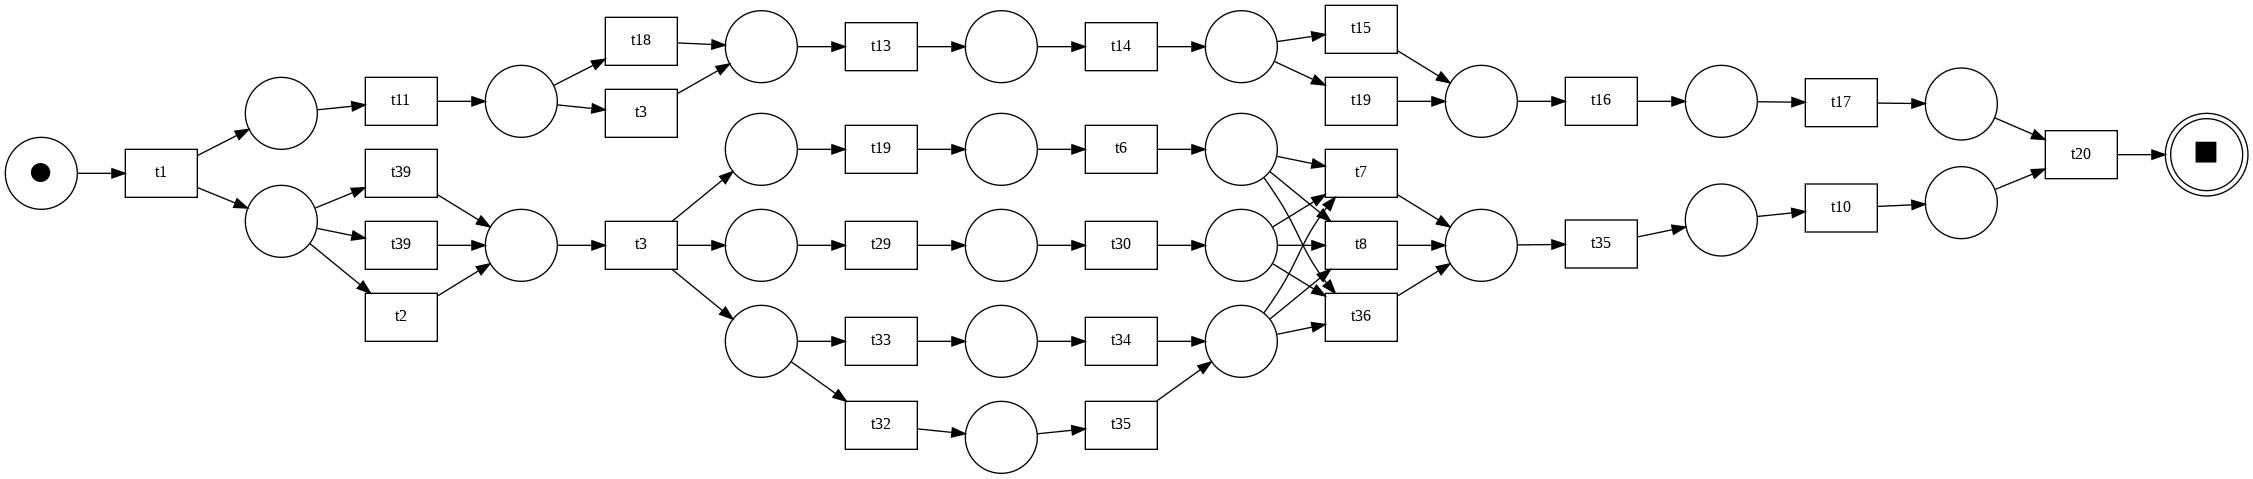

In [9]:
embeddings_vectors = pnml2vec.get_net_embeddings()
# showing Petri net and its embedding
print('Embeddings Vector:' ,embeddings_vectors[0])
print('\nPetri net model:')
index=1
pm4py.view_petri_net(petriNets[index], petriNets_im[index], petriNets_fm[index])

####Auxiliar Functions

In [25]:
os.mkdir('./figures/')

In [26]:
def reverse_dict(original_dict):
    reversed_dict = {}
    for key, value in original_dict.items():
        reversed_dict[value] = key
    return reversed_dict

def build_tree_rules(models, labels, n_clusters):
    X = np.zeros((len(models),6))
    y = np.zeros((len(models)))

    k = 0
    for cluster in range(n_clusters):
        for i in np.where(labels==cluster)[0]:
            # converting names files to features and clusters to labels
            input_string = models[i].split('.')[0].split('_')[1]
            for j, char in enumerate(input_string):
                X[k, j] = char
            y[k] = cluster
            k += 1

    clf = tree.DecisionTreeClassifier(random_state=0)
    clf = clf.fit(X, y)
    text_representation = tree.export_text(clf)
    print(text_representation)

def plot_shilhouette(embeddings_vectors, labels, file_name):

    # Compute the silhouette scores for each sample
    sample_silhouette_values = metrics.silhouette_samples(embeddings_vectors, labels)
    silhouette_avg = metrics.silhouette_score(embeddings_vectors, labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0) # Number of clusters in labels, ignoring noise if present.

    fig, ax1 = plt.subplots(figsize=(5,4))
    colors = len(sample_silhouette_values)*[0]
    y_lower = 0
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        for pos in np.where(labels == i)[0]:
            colors[int(pos)] = color
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.25 * size_cluster_i, str(i))
        # Compute the new y_lower for next plot
        y_lower = y_upper

    for pos, color in enumerate(colors):
        if color == 0:
            colors[pos] = (1.,1.,1.,1.)

    ax1.set_xlim([-0.06,np.max(ith_cluster_silhouette_values)+0.2])
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster labels")
    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label='silhouette_avg')
    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    plt.legend(loc='upper right')
    plt.savefig('./figures/'+file_name+'.png')
    plt.show()

    return colors

####Task Histogram

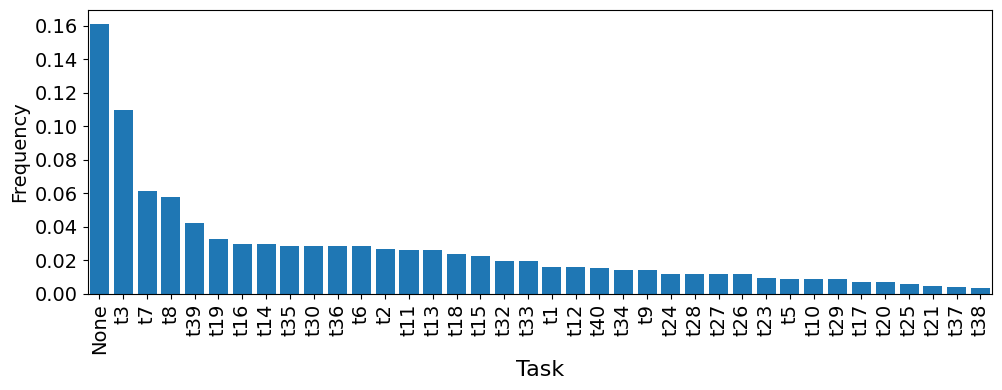

In [13]:
word_count = {key:0 for key, value in pnml2vec._task_keys.items()}

for doc in pnml2vec._documents:
    for word in doc.words:
        word_count[word] += 1

# Extract keys and values
x_ticks = list(word_count.keys())
frequencies = list(word_count.values())
frequencies = frequencies/np.sum(frequencies)

# Create the histogram
plt.figure(figsize=(10, 4))
plt.bar(x_ticks, frequencies)
plt.xlabel("Task", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(rotation=90, fontsize=14)
plt.tight_layout()
plt.xlim([-0.5,37.5])
plt.xticks()
plt.yticks(fontsize=14)
plt.savefig('./figures/histogram_methodology_1.png')
plt.show()

####HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)

In [14]:
embeddings_vectors = normalize(pnml2vec.get_net_embeddings().copy())
cluster = hdbscan.HDBSCAN(min_cluster_size=4) # Hierarchical DBSCAN with cosine similarity
labels = cluster.fit_predict(embeddings_vectors)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0) # Number of clusters in labels, ignoring noise if present.
n_noise = list(labels).count(-1)
Silhouette = metrics.silhouette_score(embeddings_vectors, labels)
davies_score = metrics.davies_bouldin_score(embeddings_vectors, labels)

print(f"Silhouette Coefficient: {Silhouette:.3f}",
        'n_clusters:', n_clusters,
        'n_noise:', n_noise,
        f"davies_score: {davies_score:.3f}")

Silhouette Coefficient: 0.634 n_clusters: 9 n_noise: 0 davies_score: 0.539


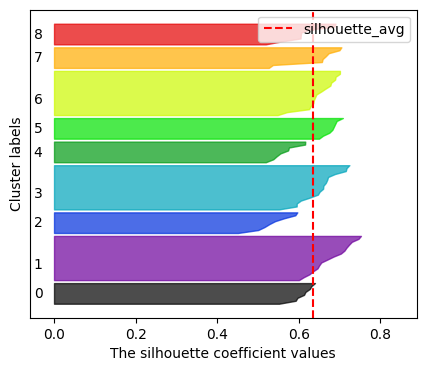

In [27]:
# Plot
colors = plot_shilhouette(embeddings_vectors, labels, file_name = 'silhouette_models')

#### UMAP Projector

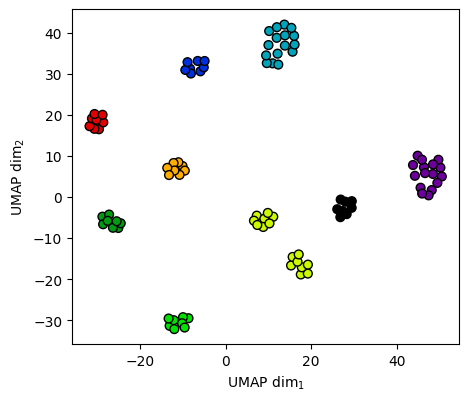

In [28]:
embeddings_vectors = normalize(pnml2vec.get_net_embeddings().copy())
reducer = umap.UMAP(metric='cosine', spread=10.0, random_state=random_seed)
embedding = reducer.fit_transform(embeddings_vectors)

plt.figure(figsize=(5, 4.35))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, cmap='Spectral', s=40, edgecolors='black')
plt.xlabel(r'UMAP dim$_1$')
plt.ylabel(r'UMAP dim$_2$')
plt.savefig('./figures/UMAP_models.png')
plt.show()

#### Cluster

In [17]:
# Cluster Members
clusters_members = {}
cluster_sizes = []

for cluster in range(n_clusters):
    print("\nCluster: ", cluster)
    clusters_members[str(cluster)] = []
    n = 0
    for i in np.where(labels==cluster)[0]:
        n += 1
        clusters_members[str(cluster)].append(models[i])
        print(i, models[i])
    cluster_sizes.append(n)


Cluster:  0
0 pdc2023_000000.pnml
2 pdc2023_000010.pnml
8 pdc2023_001000.pnml
10 pdc2023_001010.pnml
48 pdc2023_100000.pnml
50 pdc2023_100010.pnml
56 pdc2023_101000.pnml
58 pdc2023_101010.pnml

Cluster:  1
16 pdc2023_010000.pnml
18 pdc2023_010010.pnml
24 pdc2023_011000.pnml
26 pdc2023_011010.pnml
32 pdc2023_020000.pnml
34 pdc2023_020010.pnml
40 pdc2023_021000.pnml
42 pdc2023_021010.pnml
64 pdc2023_110000.pnml
66 pdc2023_110010.pnml
72 pdc2023_111000.pnml
74 pdc2023_111010.pnml
80 pdc2023_120000.pnml
82 pdc2023_120010.pnml
88 pdc2023_121000.pnml
90 pdc2023_121010.pnml

Cluster:  2
1 pdc2023_000001.pnml
3 pdc2023_000011.pnml
9 pdc2023_001001.pnml
11 pdc2023_001011.pnml
49 pdc2023_100001.pnml
51 pdc2023_100011.pnml
57 pdc2023_101001.pnml
59 pdc2023_101011.pnml

Cluster:  3
17 pdc2023_010001.pnml
19 pdc2023_010011.pnml
25 pdc2023_011001.pnml
27 pdc2023_011011.pnml
33 pdc2023_020001.pnml
35 pdc2023_020011.pnml
41 pdc2023_021001.pnml
43 pdc2023_021011.pnml
65 pdc2023_110001.pnml
67 pdc2023_

In [18]:
# Learn Rules
build_tree_rules(models, labels, n_clusters)

|--- feature_5 <= 0.50
|   |--- feature_3 <= 0.50
|   |   |--- feature_1 <= 0.50
|   |   |   |--- class: 0.0
|   |   |--- feature_1 >  0.50
|   |   |   |--- class: 1.0
|   |--- feature_3 >  0.50
|   |   |--- feature_1 <= 0.50
|   |   |   |--- class: 4.0
|   |   |--- feature_1 >  0.50
|   |   |   |--- feature_2 <= 0.50
|   |   |   |   |--- class: 8.0
|   |   |   |--- feature_2 >  0.50
|   |   |   |   |--- class: 7.0
|--- feature_5 >  0.50
|   |--- feature_3 <= 0.50
|   |   |--- feature_1 <= 0.50
|   |   |   |--- class: 2.0
|   |   |--- feature_1 >  0.50
|   |   |   |--- class: 3.0
|   |--- feature_3 >  0.50
|   |   |--- feature_1 <= 0.50
|   |   |   |--- class: 5.0
|   |   |--- feature_1 >  0.50
|   |   |   |--- class: 6.0



pdc2023_000000.pnml


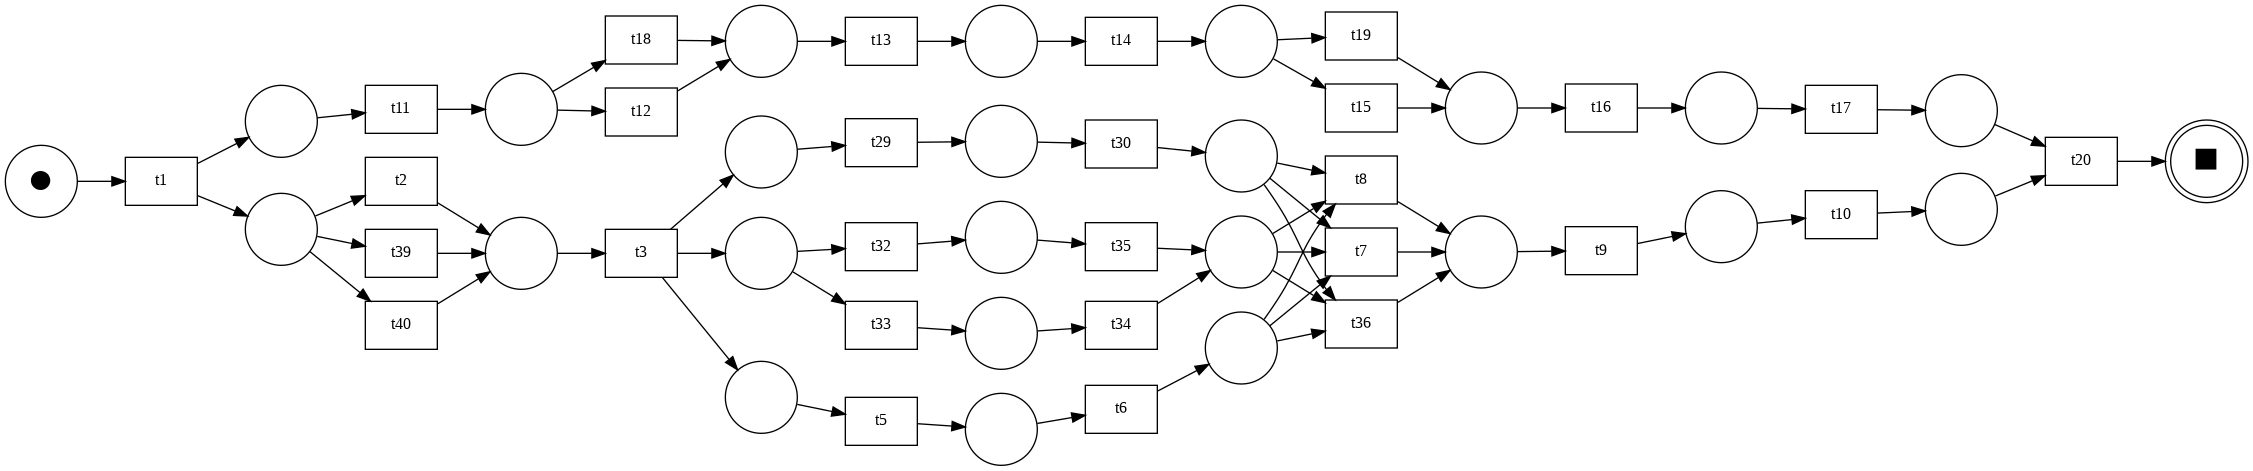

pdc2023_000010.pnml


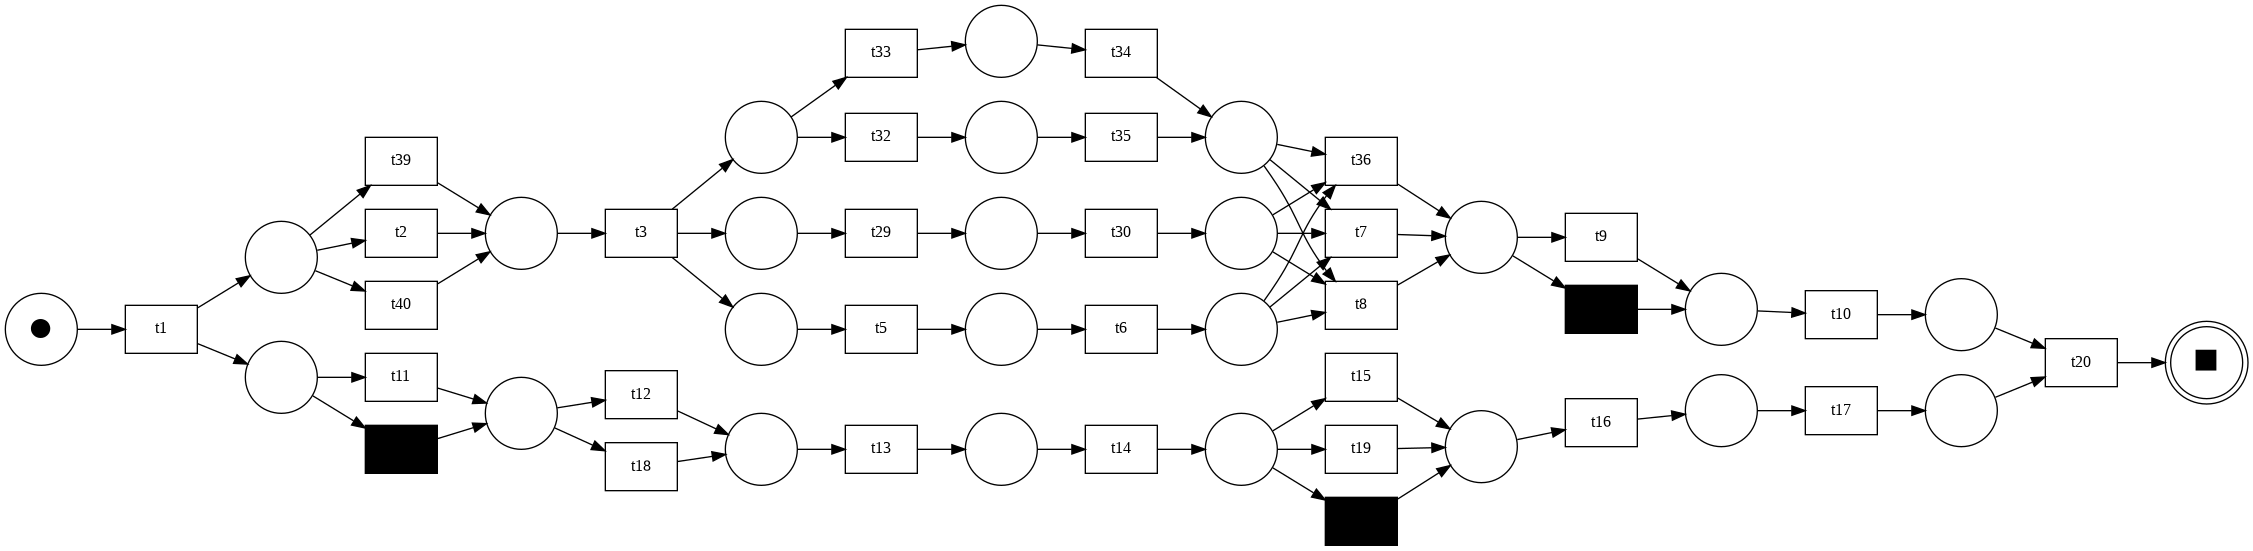

pdc2023_001000.pnml


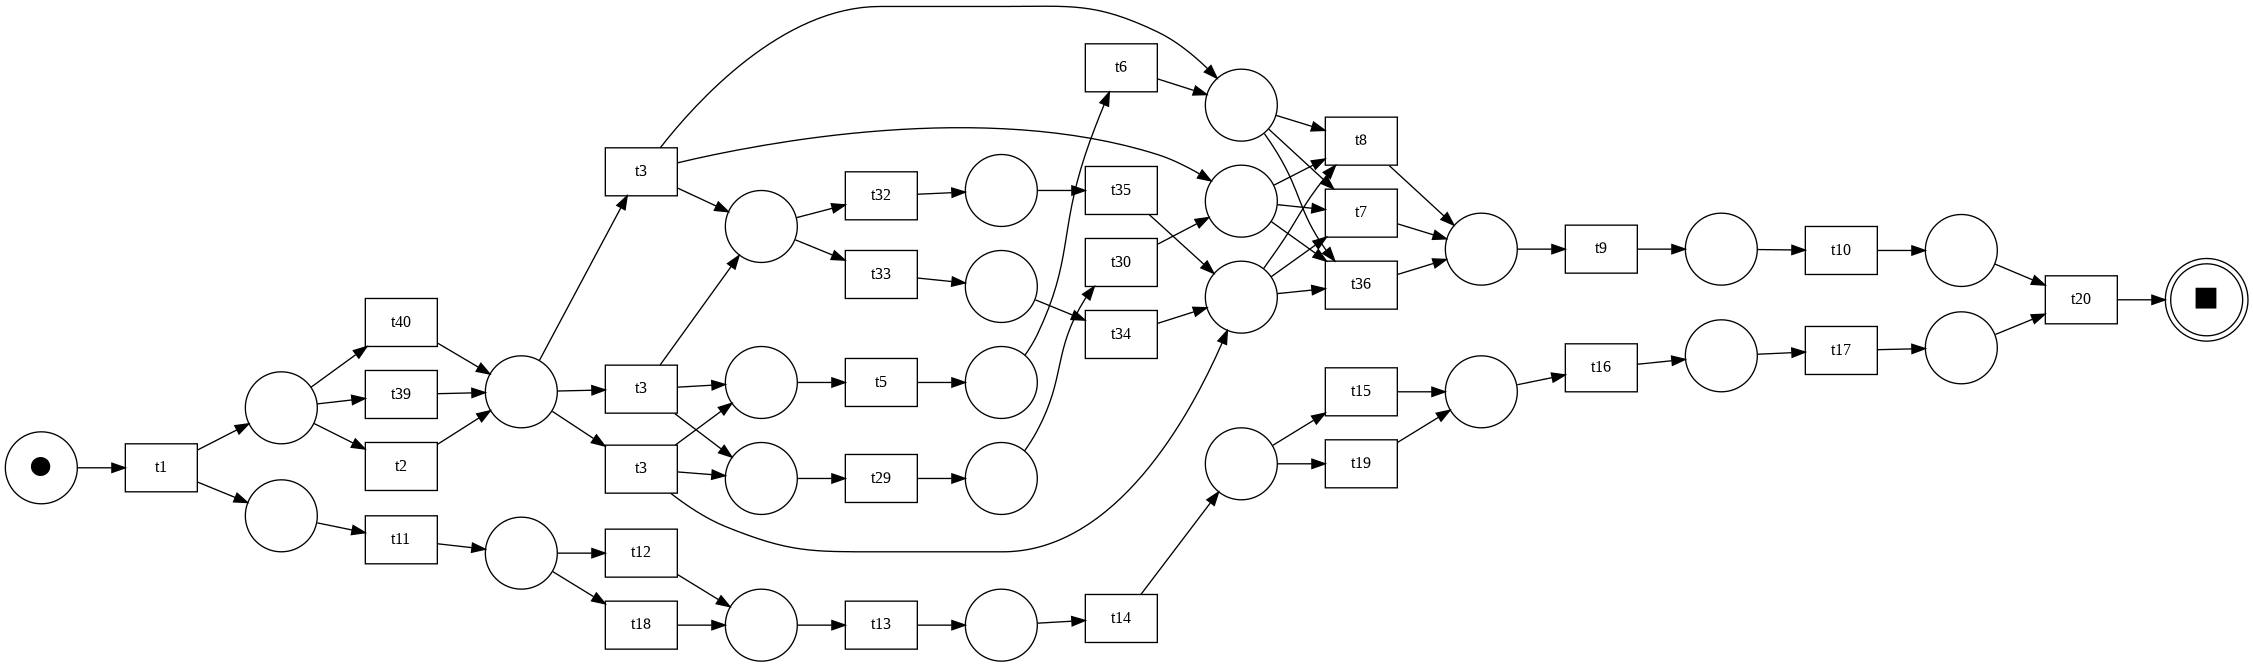

pdc2023_001010.pnml


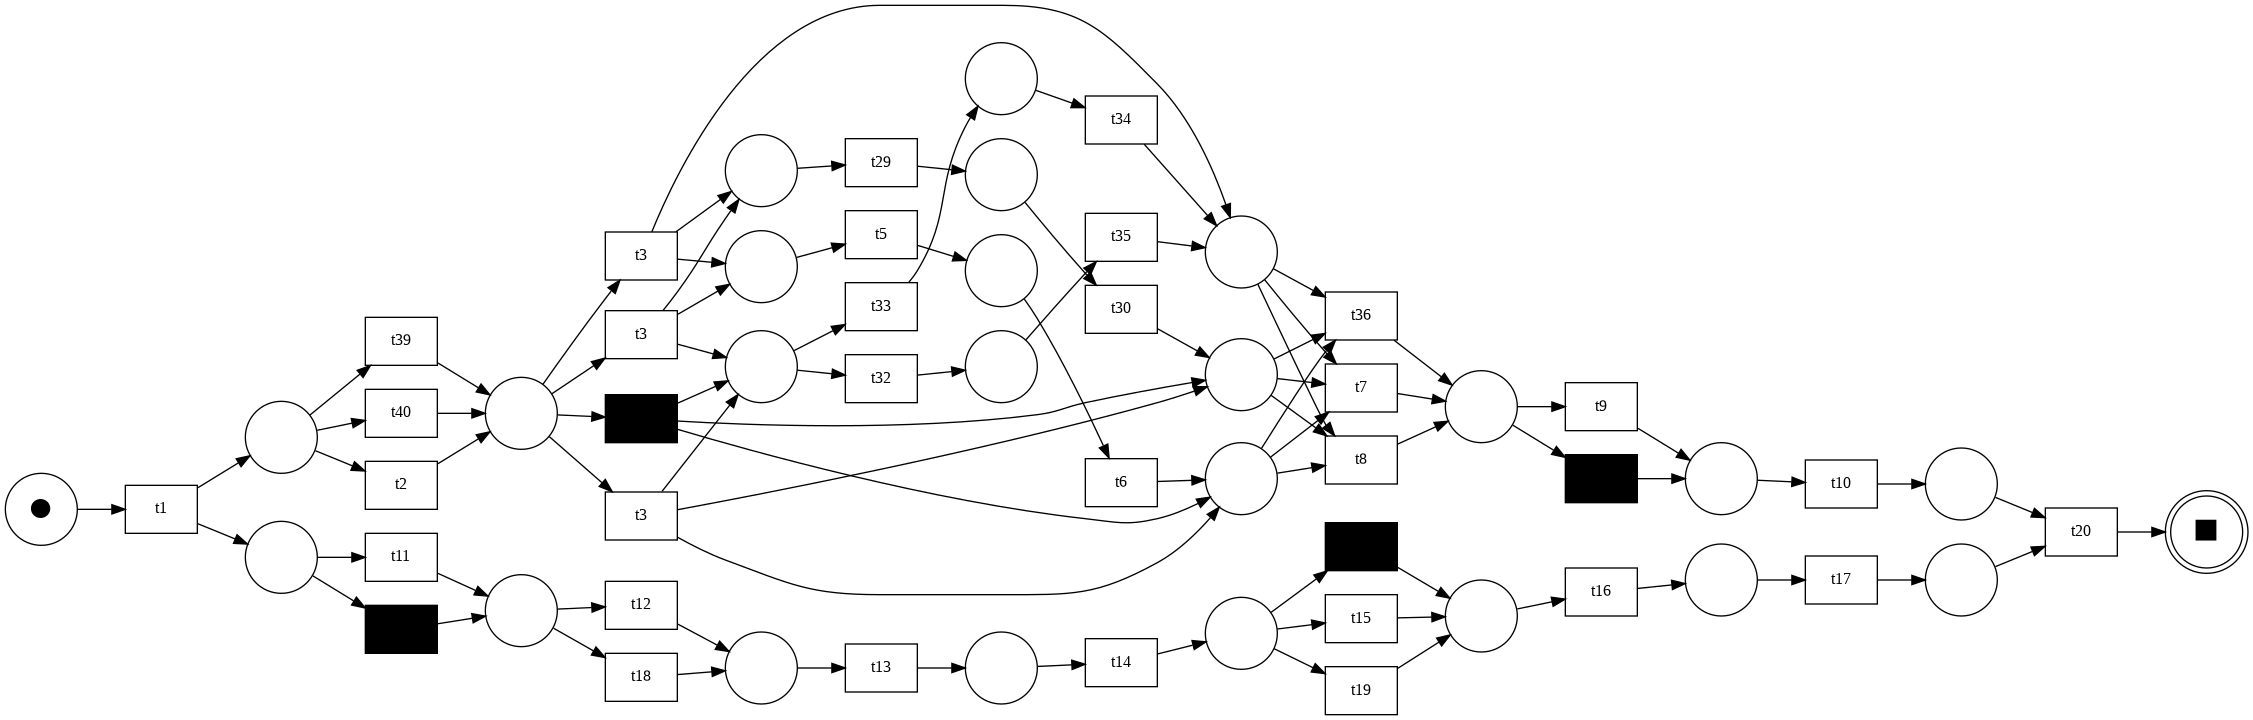

In [21]:
# showing the fisrt four cluster members
for i, member in enumerate(clusters_members['0']):
    if i < 4:
        print(member)
        net, im, fm = pm4py.read_pnml(os.path.join('./Models/', member))
        pm4py.view_petri_net(net, im, fm)

pdc2023_010100.pnml


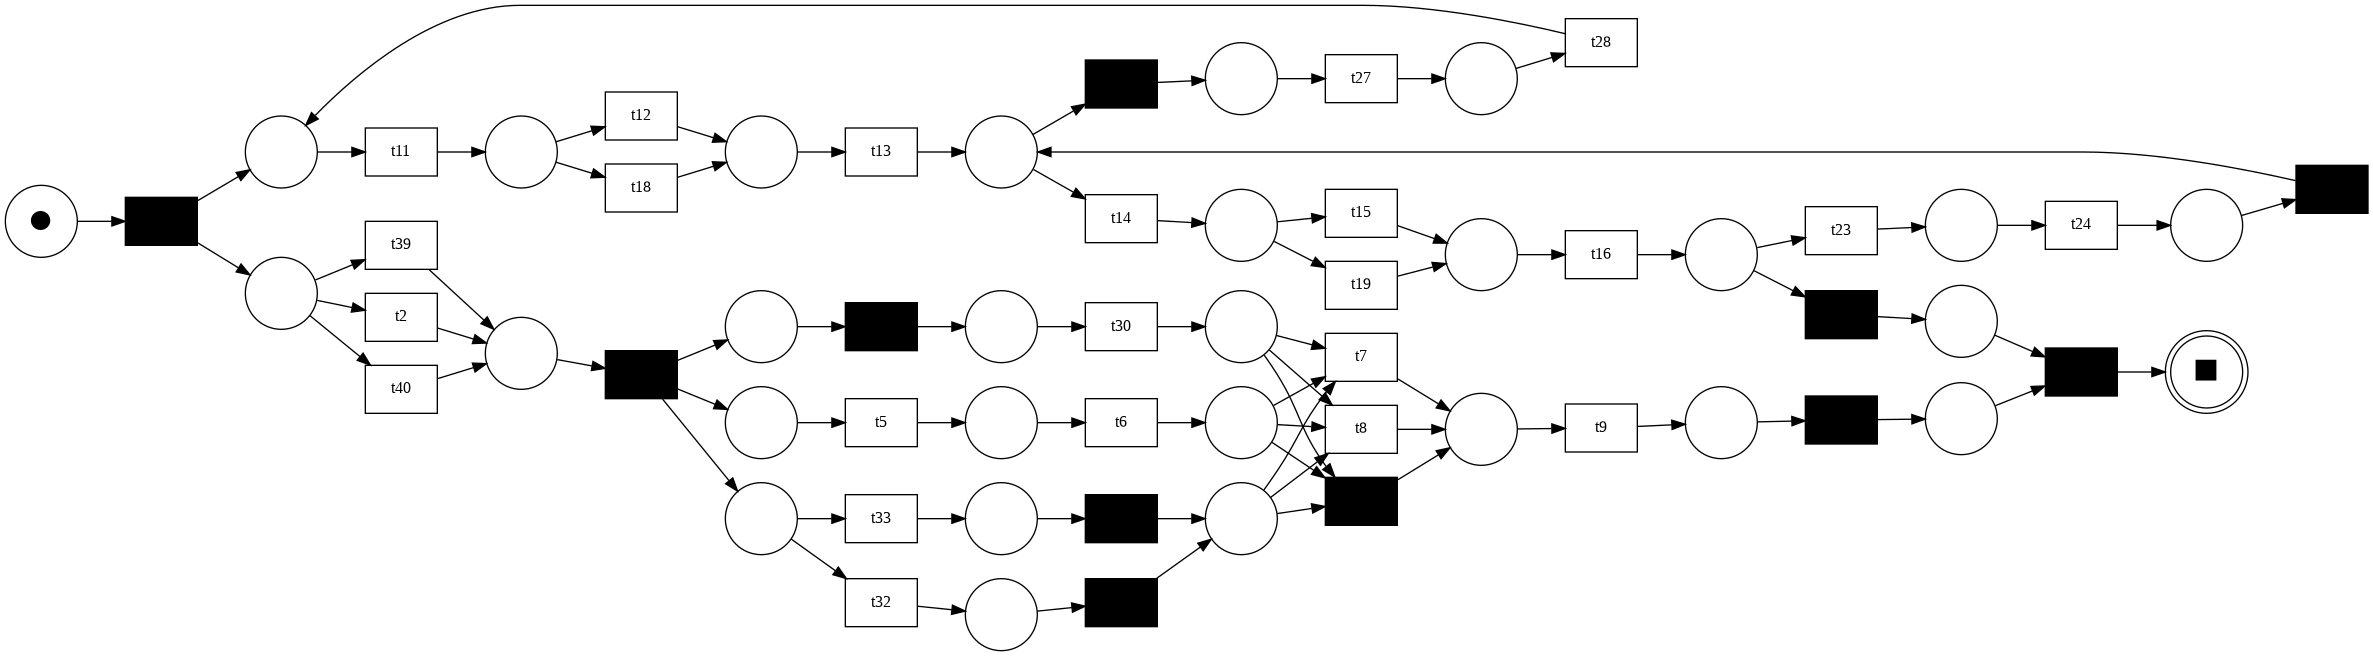

36 pdc2023_020100.pnml


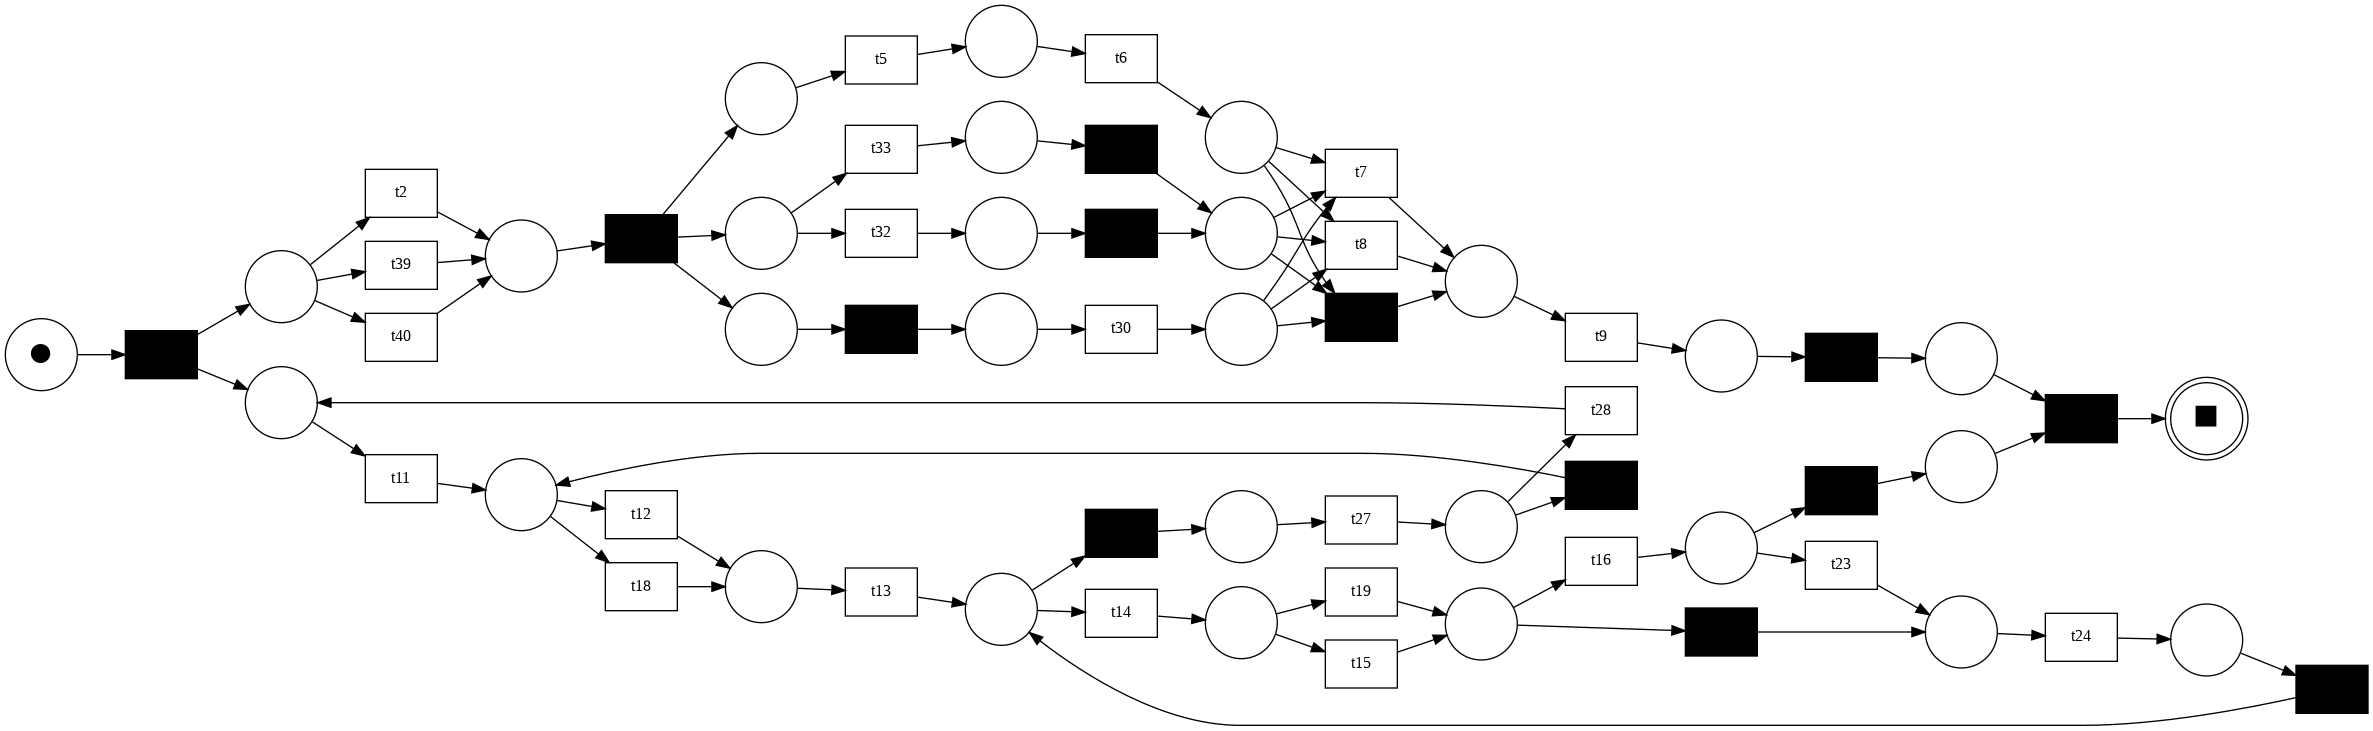

In [22]:
# Solving similar query model
j = '20'
net_id = pnml2vec._net_keys[j]

print(models[net_id])
pm4py.view_petri_net(petriNets[net_id], petriNets_im[net_id], petriNets_fm[net_id])


models_embeddings = normalize(pnml2vec.get_net_embeddings().copy())
sim_matrix = [pnml2vec.similarity(embedding, models_embeddings[net_id]) for embedding in models_embeddings]
nearest_neighbor = np.argsort(sim_matrix)[::-1][2]

print(nearest_neighbor, models[nearest_neighbor])
pm4py.view_petri_net(petriNets[nearest_neighbor], petriNets_im[nearest_neighbor], petriNets_fm[nearest_neighbor])

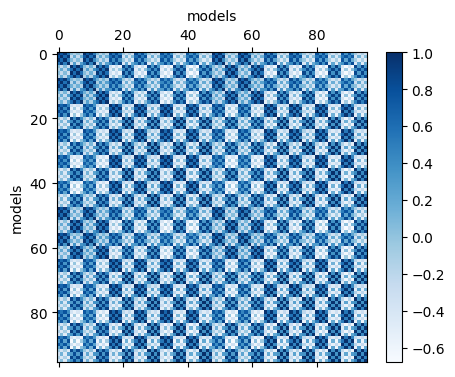

In [29]:
# Similarity matrix between embedding models
models_embeddings = normalize(pnml2vec.get_net_embeddings().copy())
matrix_models = cosine_similarity(models_embeddings)

# Create the heatmap
plt.figure(figsize=(5,4))
plt.matshow(matrix_models, cmap="Blues", fignum=1)  # Adjust cmap for different color schemes
plt.colorbar()
plt.clim(np.min(matrix_models), 1)
plt.title('models', fontsize=10)
plt.ylabel('models')
plt.savefig('./figures/models_similarity_matrix.png')
plt.show()

####Model classification tasks

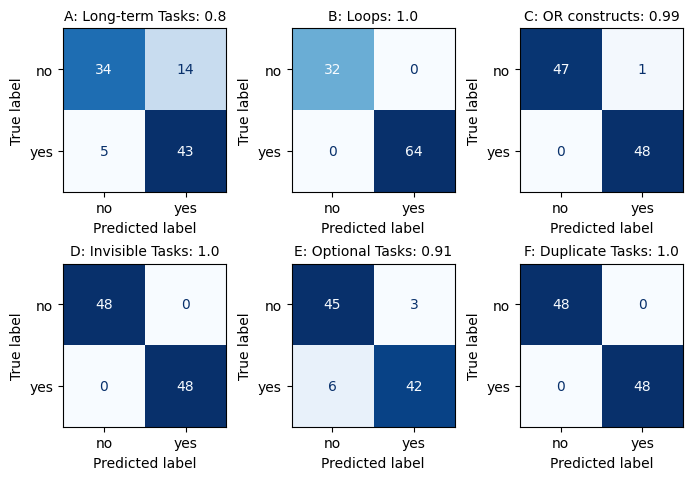

In [31]:
models_embeddings = normalize(pnml2vec.get_net_embeddings().copy())
rules = ['A: Long-term Tasks', 'B: Loops', 'C: OR constructs', 'D: Invisible Tasks', 'E: Optional Tasks', 'F: Duplicate Tasks']

fig, axs = plt.subplots(2,3,figsize=(8,5.6))
for i_rule, ax in zip(enumerate(rules), axs.ravel()):
    i, rule = i_rule
    y_true = []
    for model in models:
        if model.split('_')[1].split('.')[0][i] == '0':
            y_true.append(0)
        else:
            y_true.append(1)

    #clf = RandomForestClassifier(random_state=random_seed)
    clf = KNeighborsClassifier(n_neighbors=1, metric='cosine')

    y_pred = cross_val_predict(clf, models_embeddings, y_true, cv=10)
    acc = metrics.accuracy_score(y_true, y_pred)

    img = metrics.ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                                                          display_labels=['no', 'yes'],
                                                          cmap=plt.cm.Blues,
                                                          colorbar=False,
                                                          ax=ax)
    ax.set_title(rule + ': ' + str(np.round(acc, 2)), fontsize=10)
fig.subplots_adjust(wspace=0.4)
plt.show()

####Cluster of task embeddings - HDBSCAN

In [32]:
embeddings_vectors = normalize(pnml2vec.get_task_embeddings().copy())
cluster = hdbscan.HDBSCAN(min_cluster_size=2) # Hierarchical DBSCAN with cosine similarity
labels_task = cluster.fit_predict(embeddings_vectors)
n_clusters_tasks = len(set(labels_task)) - (1 if -1 in labels_task else 0) # Number of clusters in labels, ignoring noise if present.
n_noise = list(labels_task).count(-1)
Silhouette = metrics.silhouette_score(embeddings_vectors, labels_task)
davies_score = metrics.davies_bouldin_score(embeddings_vectors, labels_task)

print(f"Silhouette Coefficient: {Silhouette:.3f}",
        'n_clusters:', n_clusters_tasks,
        'n_noise:', n_noise,
        f"davies_score: {davies_score:.3f}")

Silhouette Coefficient: 0.164 n_clusters: 7 n_noise: 10 davies_score: 1.774


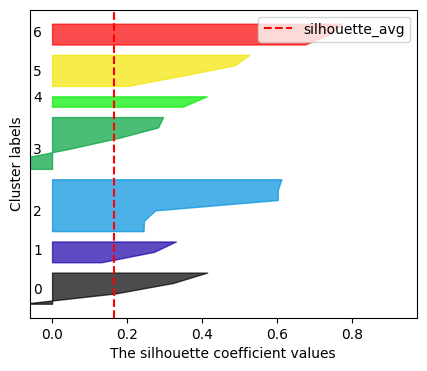

In [33]:
colors = plot_shilhouette(embeddings_vectors, labels_task, file_name = 'silhouette_task')

####UMAP task embeddings

In [34]:
embeddings_vectors = normalize(pnml2vec.get_task_embeddings().copy())
reducer = umap.UMAP(metric='cosine', spread=5, random_state=random_seed)
embedding = reducer.fit_transform(embeddings_vectors)

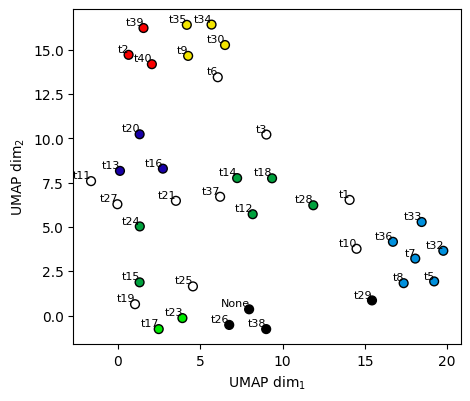

In [35]:
for pos, color in enumerate(colors):
    if color == 0:
        colors[pos] = (1.,1.,1.,1.)

plt.figure(figsize=(5, 4.35))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, cmap='Spectral', s=40, edgecolors='black')
for key, value in pnml2vec._task_keys.items():
    plt.text(embedding[value,0]+0.03, embedding[value,1]+0.03, key, fontsize=8, ha='right', va='bottom')

#plt.colorbar()
plt.xlabel(r'UMAP dim$_1$')
plt.ylabel(r'UMAP dim$_2$')
plt.savefig('./figures/UMAP_task.png')
plt.show()

####Query an specific task

In [36]:
query = 't40'
task_embeddings = normalize(pnml2vec.get_task_embeddings().copy())
task1 = pnml2vec.get_task_embeddings(query).copy()
sim_matrix = [pnml2vec.similarity(task1, embedding) for embedding in task_embeddings]
nearest_neighbor = np.argsort(sim_matrix)[::-1][2]
keys_task = reverse_dict(pnml2vec._task_keys)
print('query:', query, 'result:', keys_task[int(nearest_neighbor)])

query: t40 result: t2


####Similarity matrix between tasks

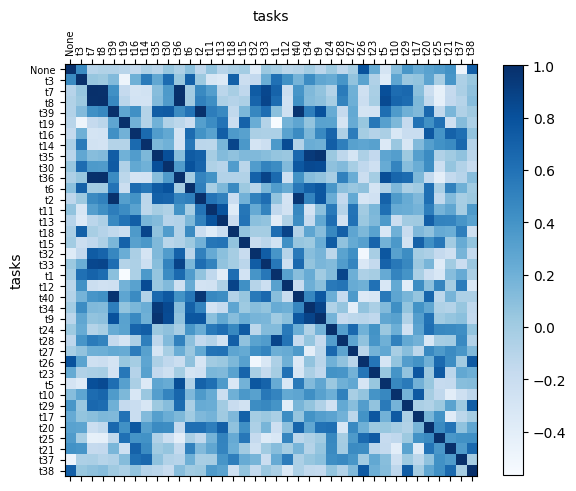

In [37]:
task_embeddings = normalize(pnml2vec.get_task_embeddings().copy())
matrix_tasks = cosine_similarity(task_embeddings)

task_keys = []
for key, value in pnml2vec._task_keys.items():
    task_keys.append(key)

fig, ax = plt.subplots(figsize=(6,6))
cax = ax.matshow(matrix_tasks, cmap="Blues")
ax.set_yticks(range(len(task_keys)))
ax.set_xticks(range(len(task_keys)))
ax.set_yticklabels(task_keys, fontsize=7)
ax.set_xticklabels(task_keys, rotation=90, fontsize=7)
cbar = fig.colorbar(cax, shrink=0.73)  # Colorbar associated with the matrix
cbar.set_label('',fontsize=7)

plt.title('tasks', fontsize=10)
plt.ylabel('tasks')
plt.tight_layout()
plt.savefig('./figures/task_similarity_matrix.png')
plt.show()

####Similarity matrix between models and tasks

In [38]:
models_embeddings = normalize(pnml2vec.get_net_embeddings().copy())
X = []
models_names = []
cluster_labels = []
for cluster in range(n_clusters):
    for i in np.where(labels==cluster)[0]:
        X.append(models_embeddings[i,:])
        models_names.append(models[i].split('_')[1].split('.')[0])
        cluster_labels.append(str(cluster))
X = np.array(X)
matrix_models_tasks = cosine_similarity(task_embeddings, X)

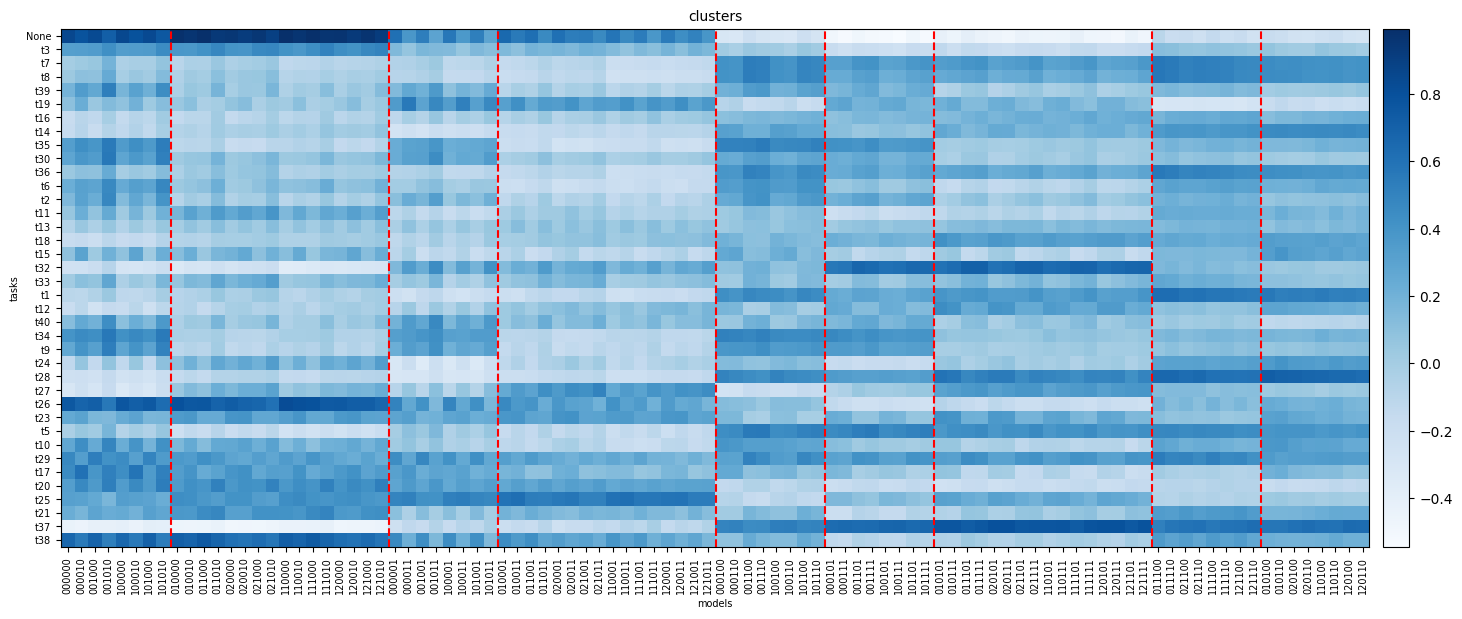

In [39]:
fig, ax = plt.subplots(figsize=(15,6))

cax = ax.imshow(matrix_models_tasks, cmap="Blues")
ax.set_xticks(np.linspace(0, len(models_names)-1, len(models_names)))
ax.set_xticklabels(models_names, rotation=90, fontsize=7)

ax.set_yticks(range(len(task_keys)))
ax.set_yticklabels(task_keys, fontsize=7)

ax.set_xlabel('models', fontsize=7)
ax.set_ylabel('tasks', fontsize=7)

cum_sum = 0
for size in cluster_sizes[:-1]:
    cum_sum += size
    ax.axvline(x=cum_sum-0.45, color='red', linestyle='--', ymin=0, ymax=1)

cbar = fig.colorbar(cax, pad=0.01, fraction=0.05 )  # Colorbar associated with the matrix
cbar.set_label('',fontsize=7)
plt.title('clusters', fontsize=10)
plt.tight_layout()
plt.savefig('./figures/similarity_matrix_models_vs_tasks.png')
plt.show()

#### Showing the fisrt four cluster members and relataed tasks

pdc2023_010000.pnml


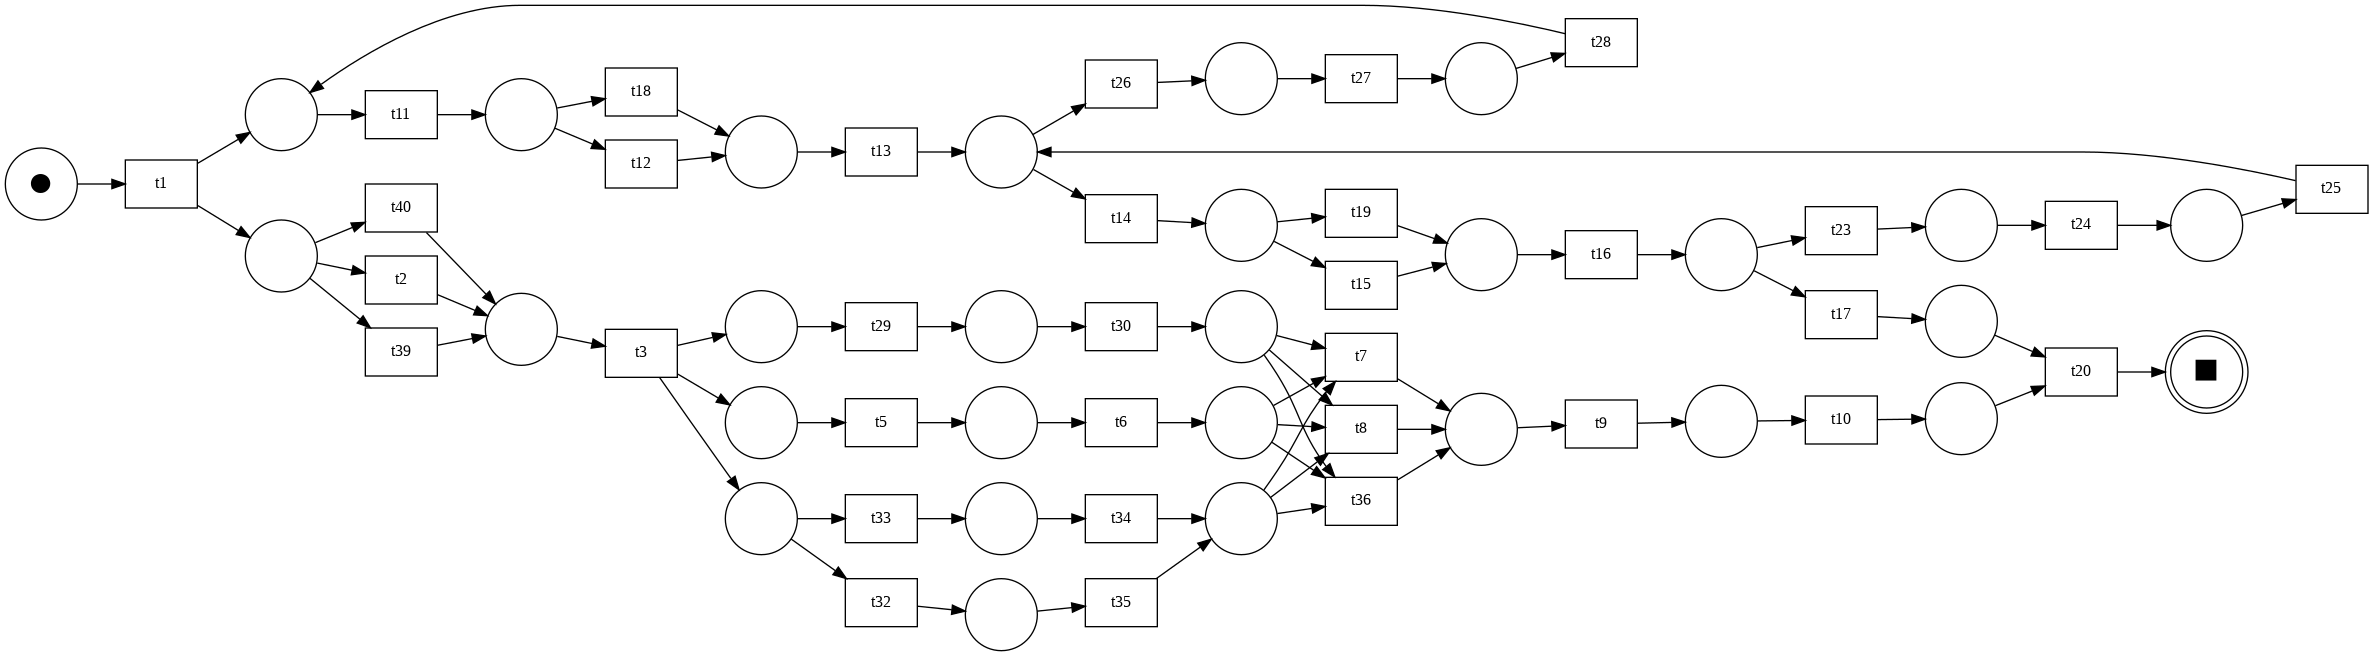

pdc2023_010010.pnml


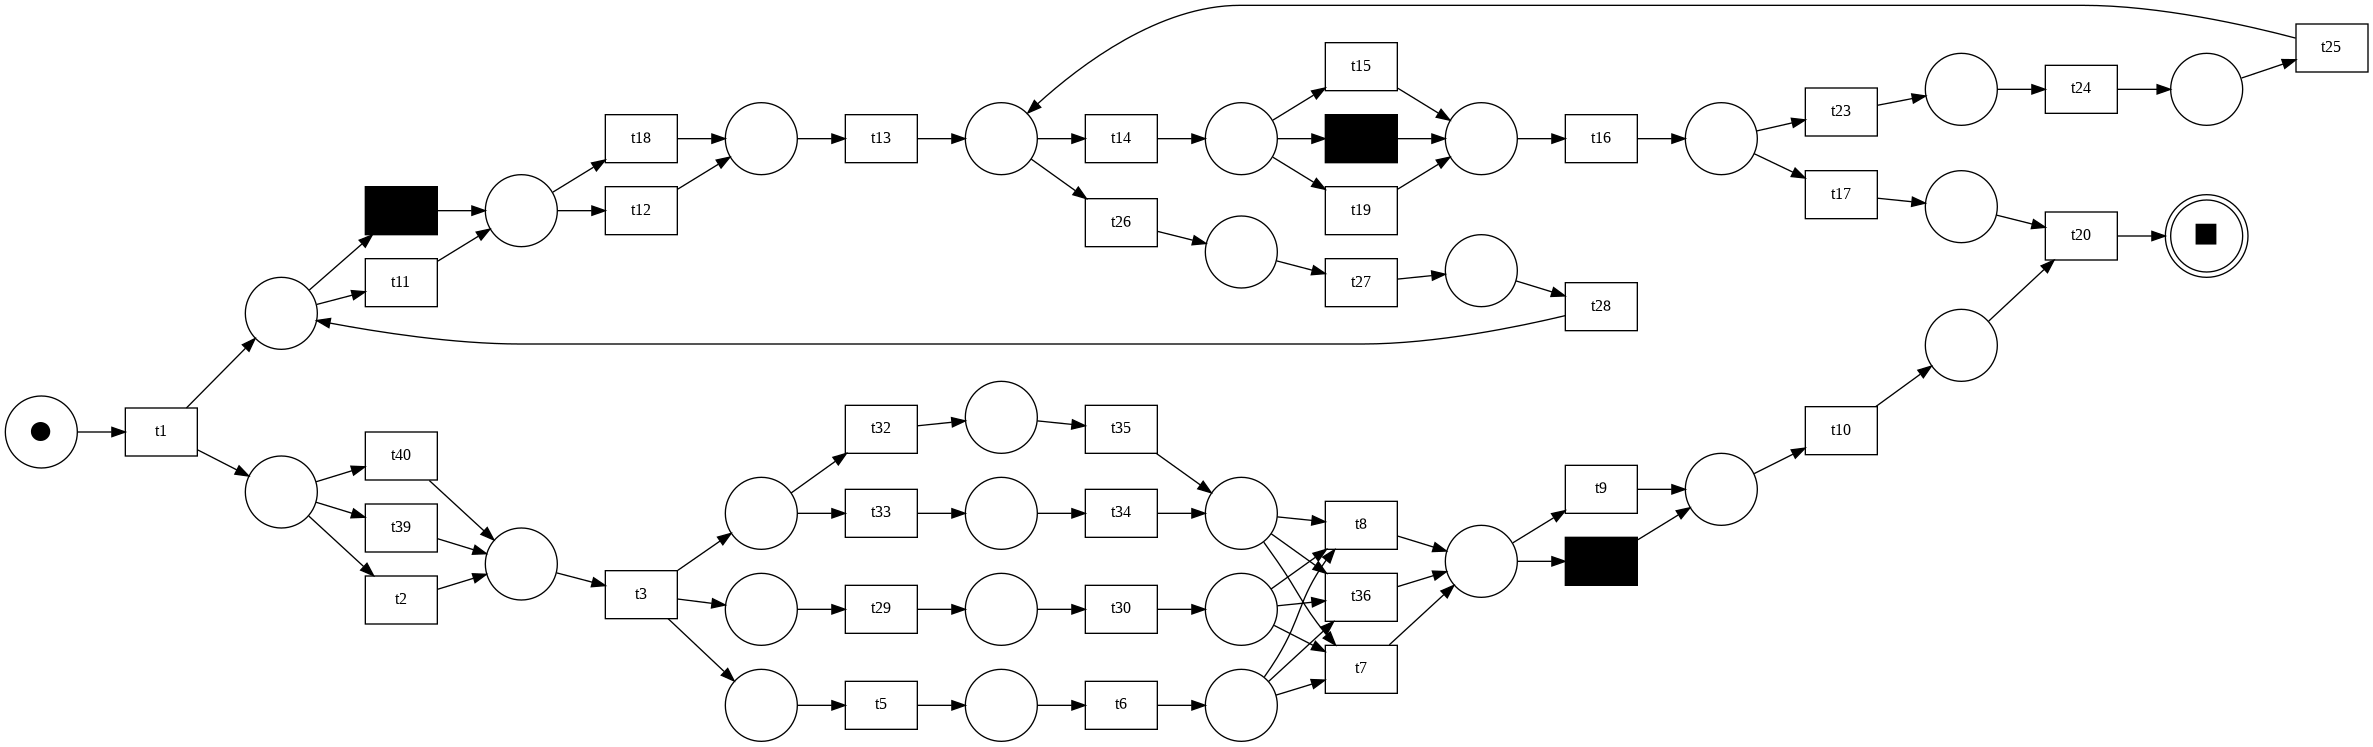

pdc2023_011000.pnml


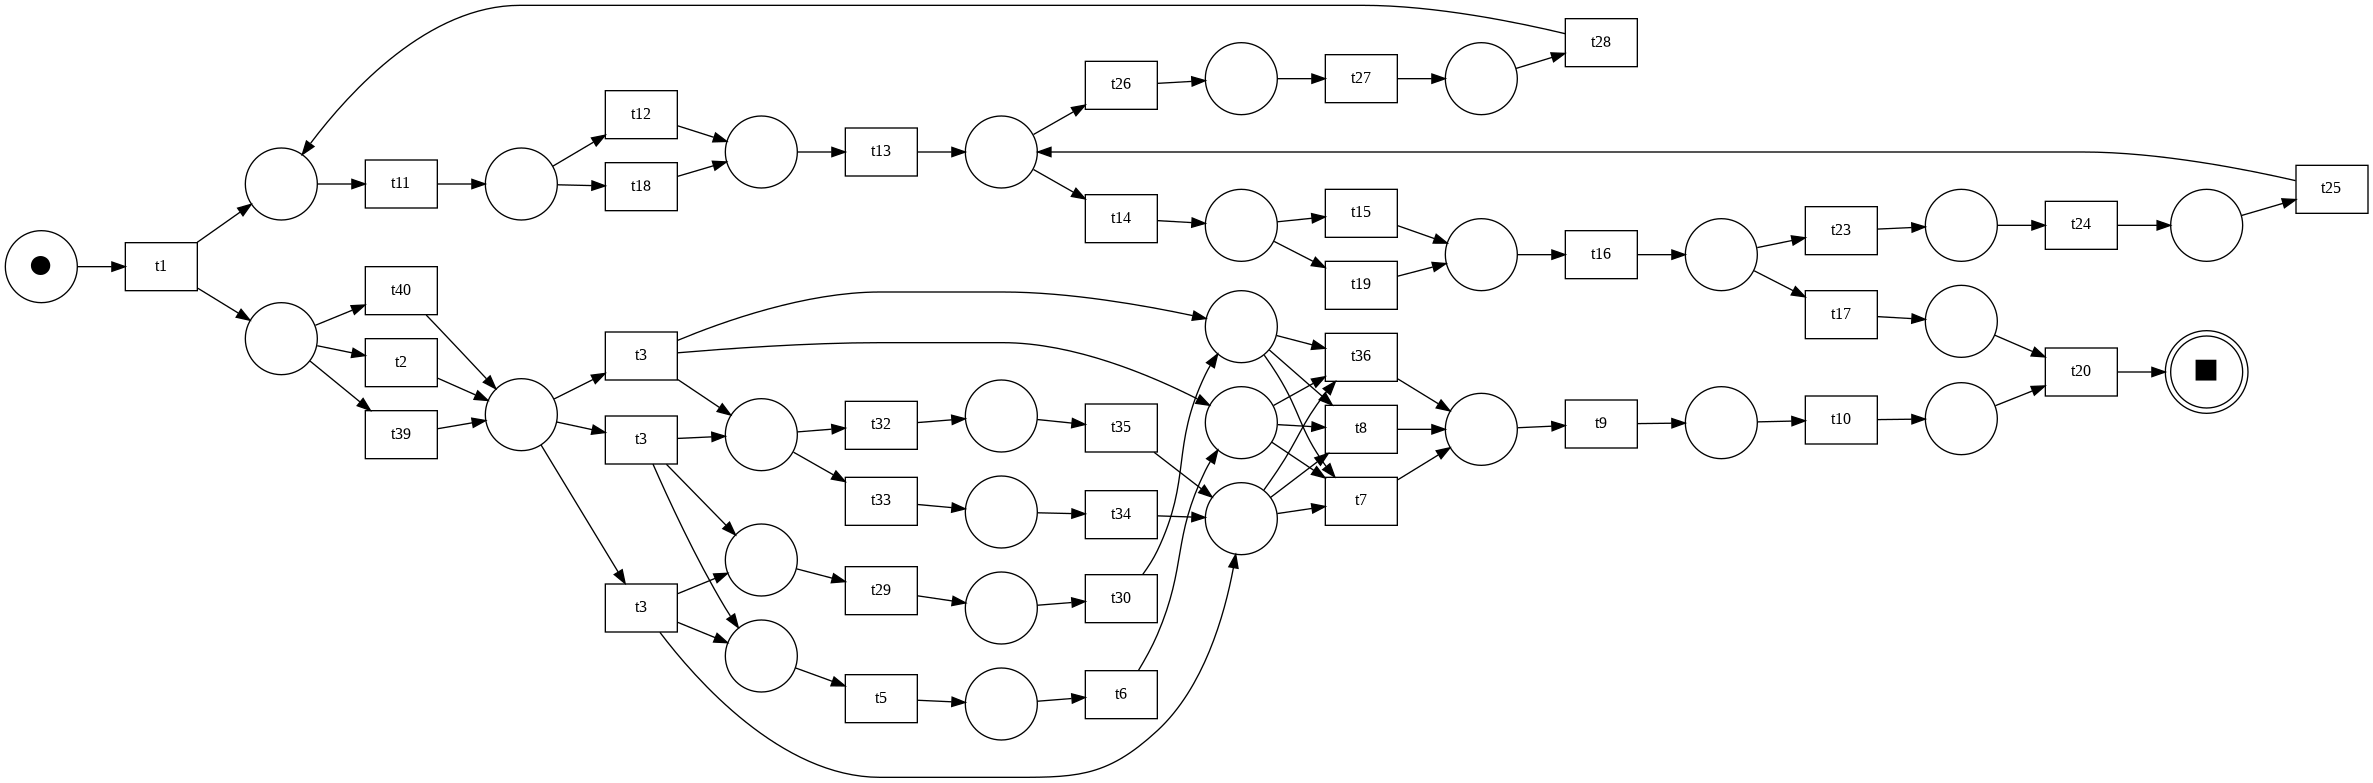

pdc2023_011010.pnml


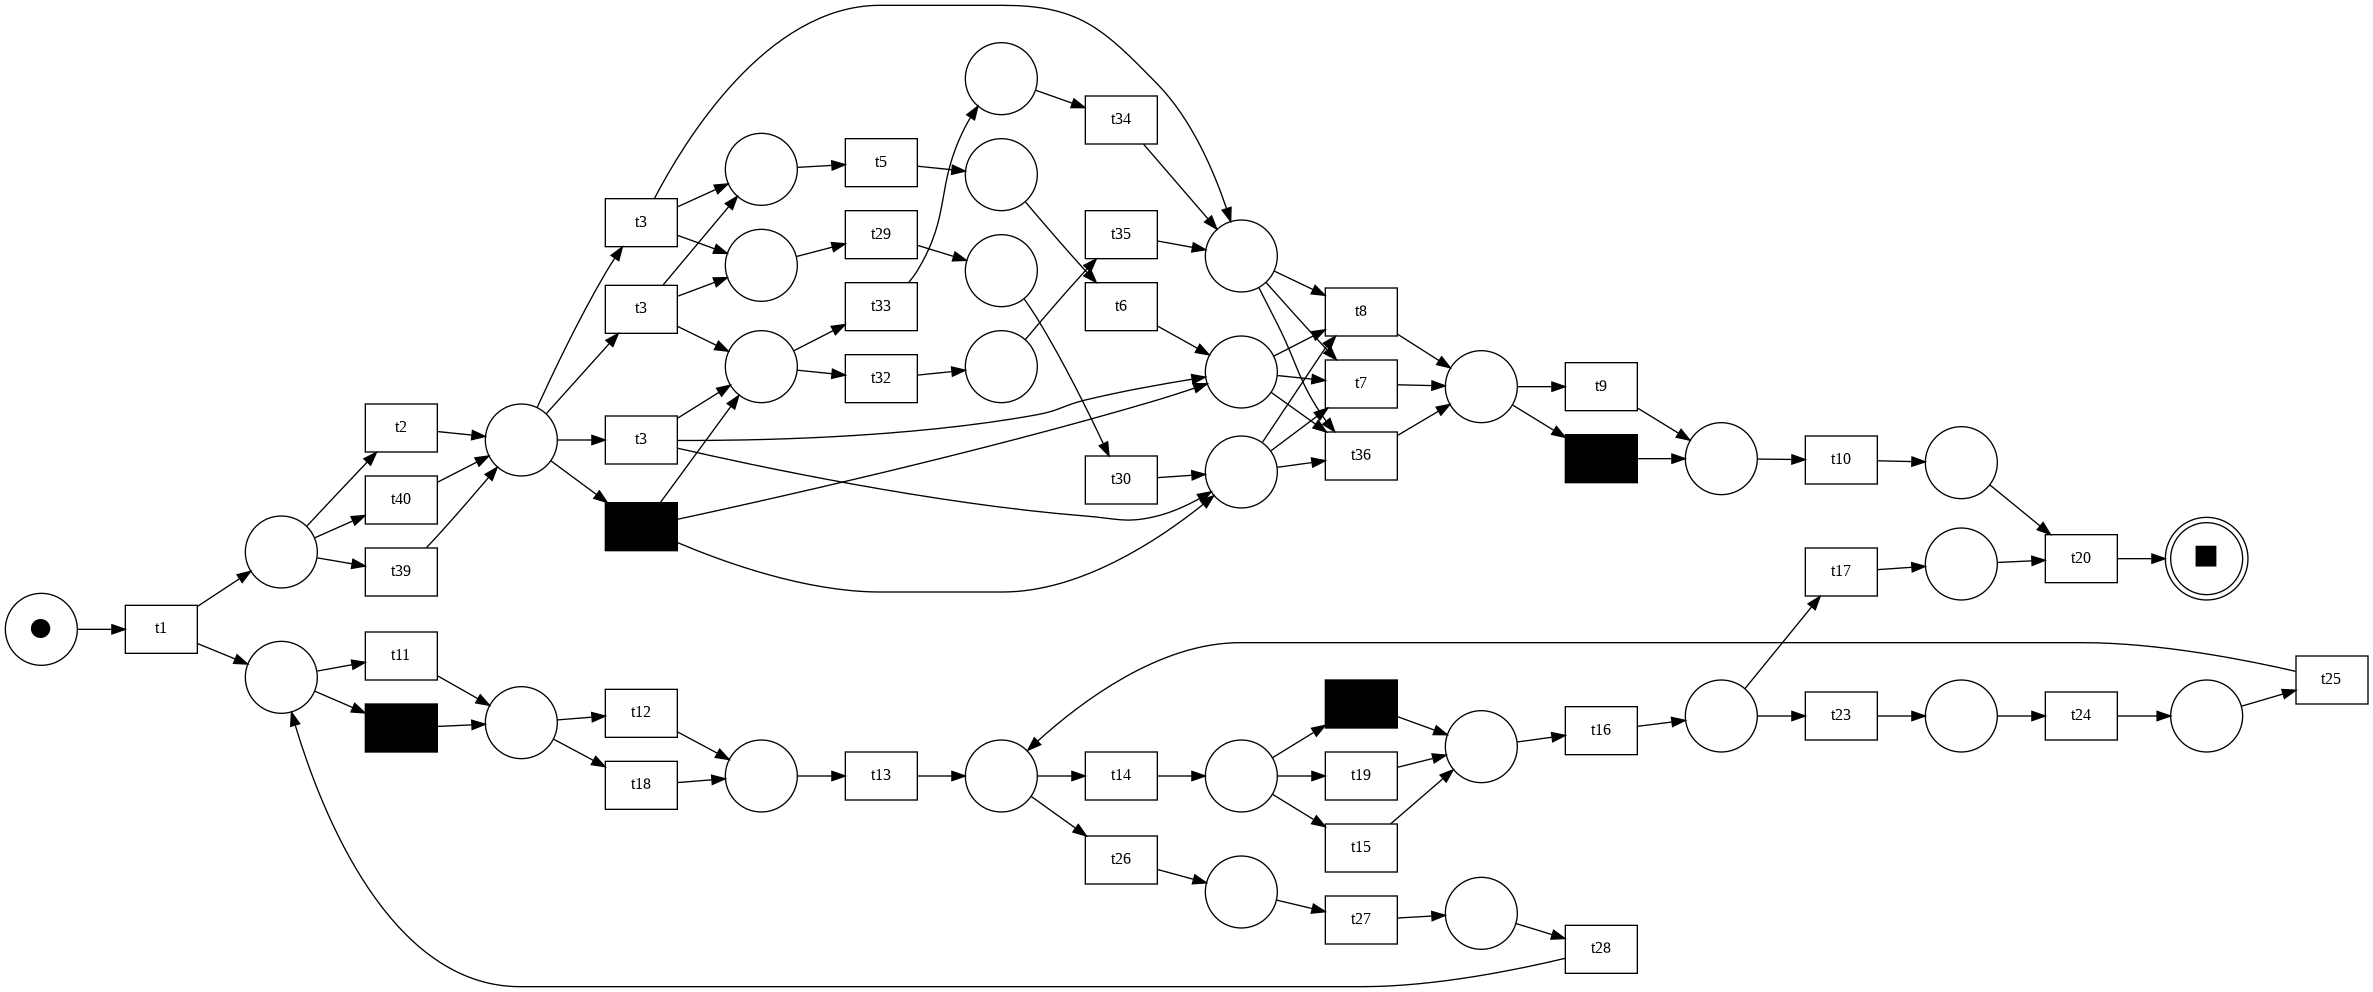

pdc2023_020000.pnml


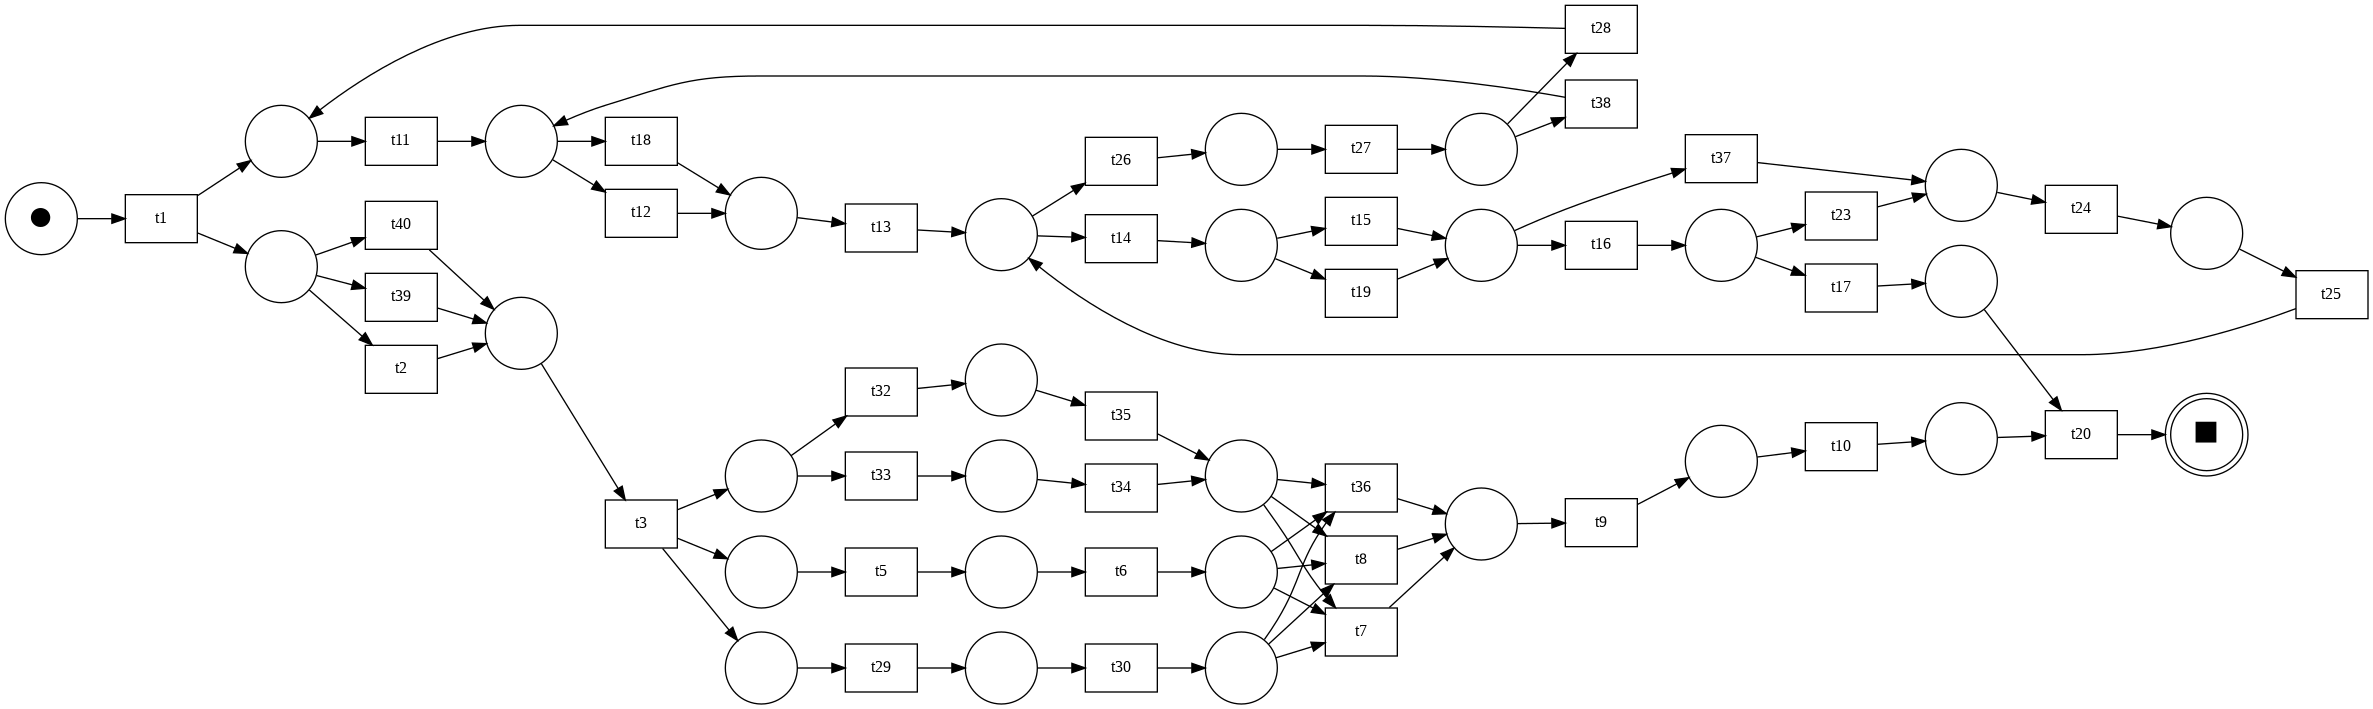

pdc2023_020010.pnml


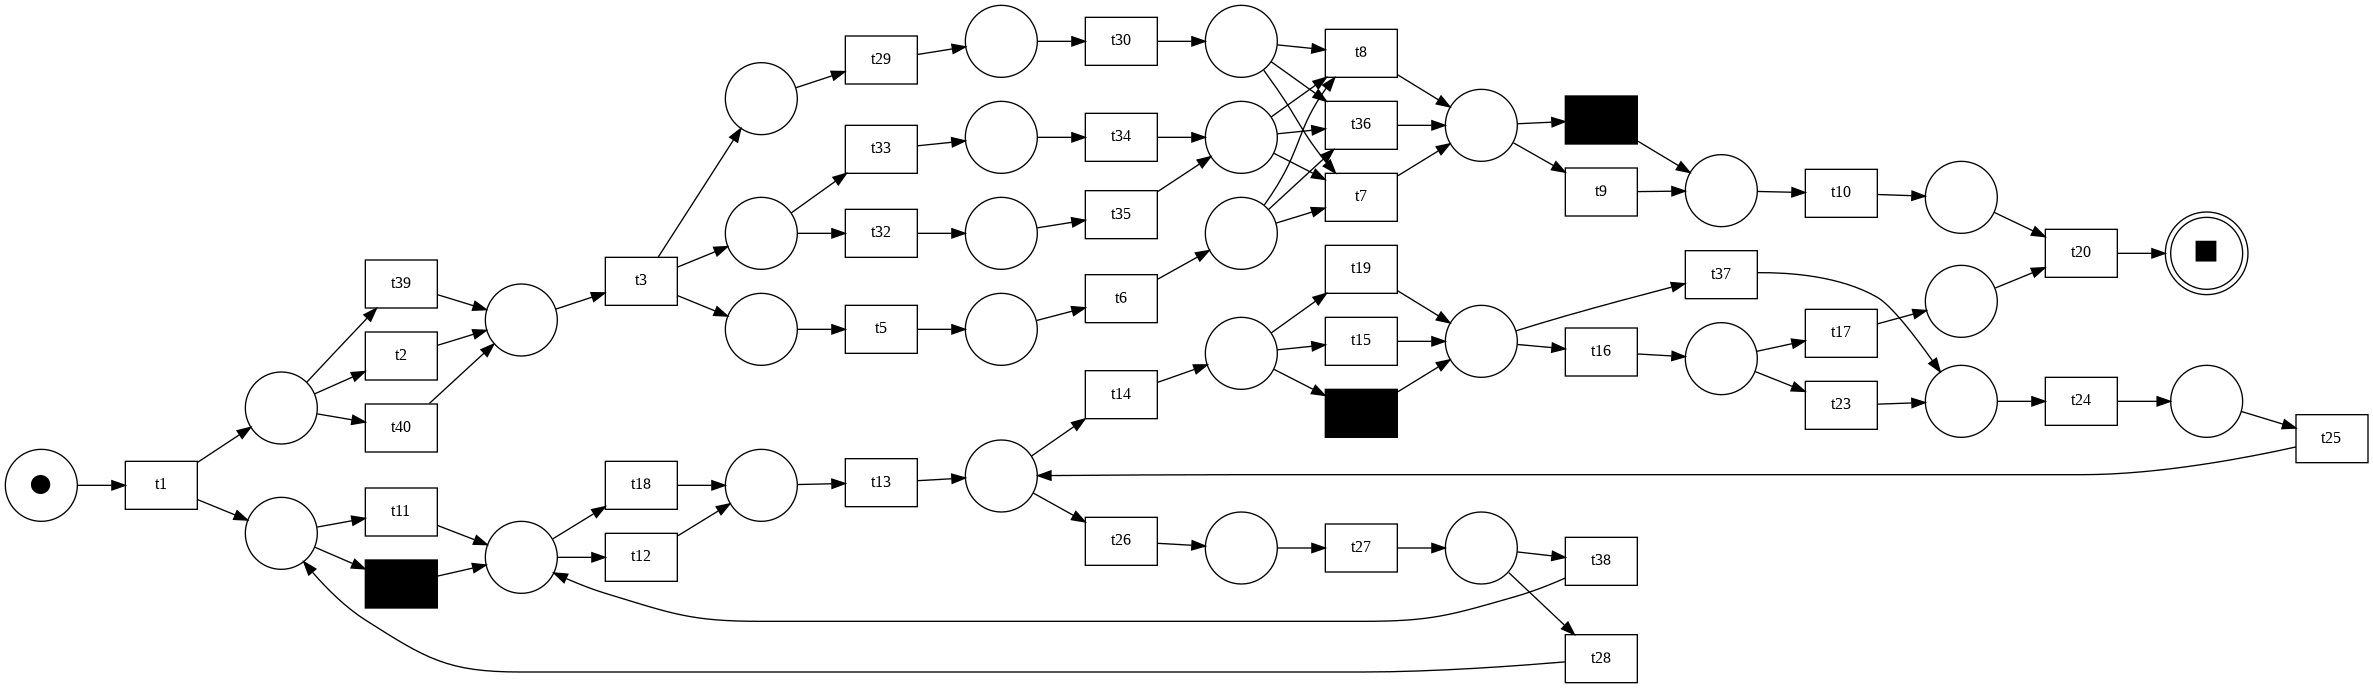

pdc2023_021000.pnml


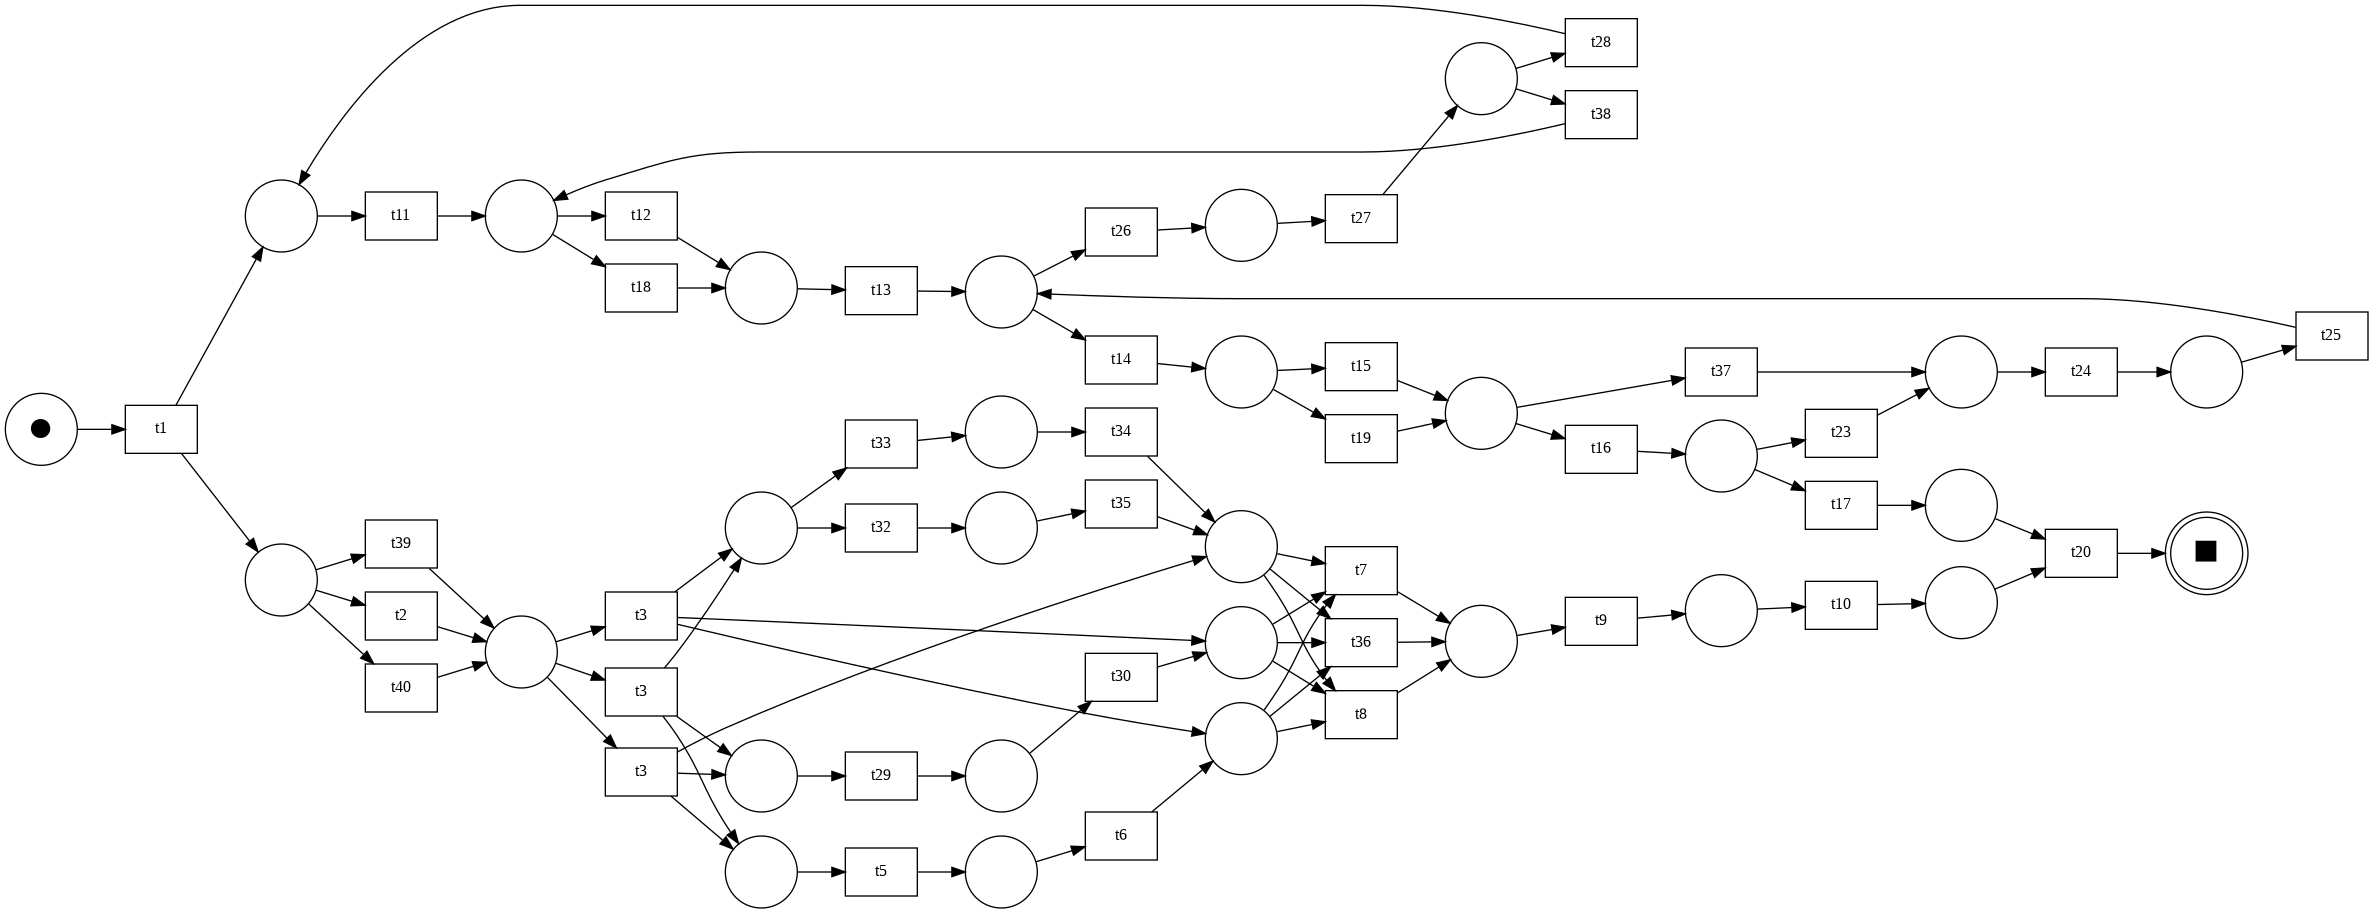

pdc2023_021010.pnml


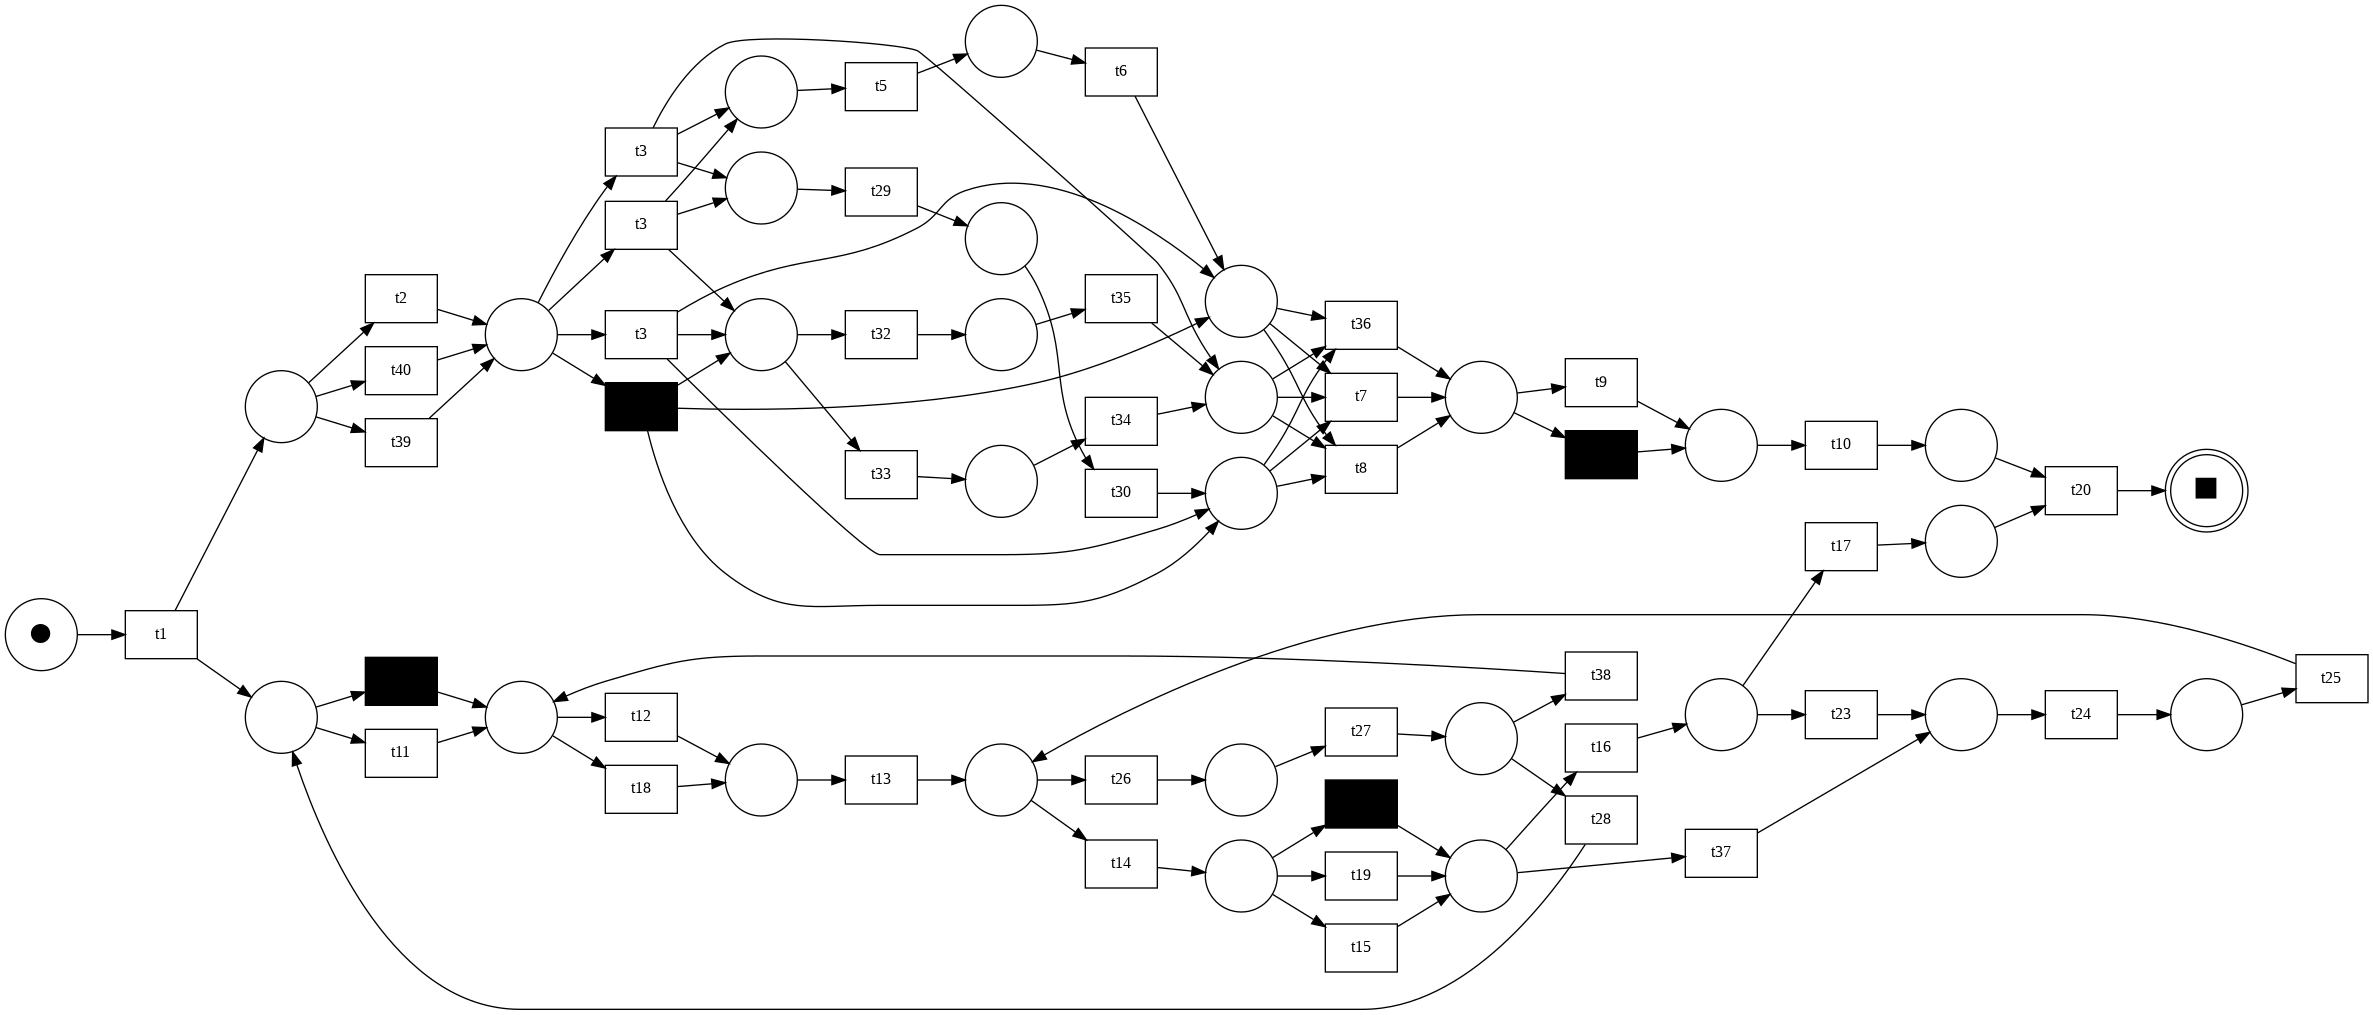

pdc2023_110000.pnml


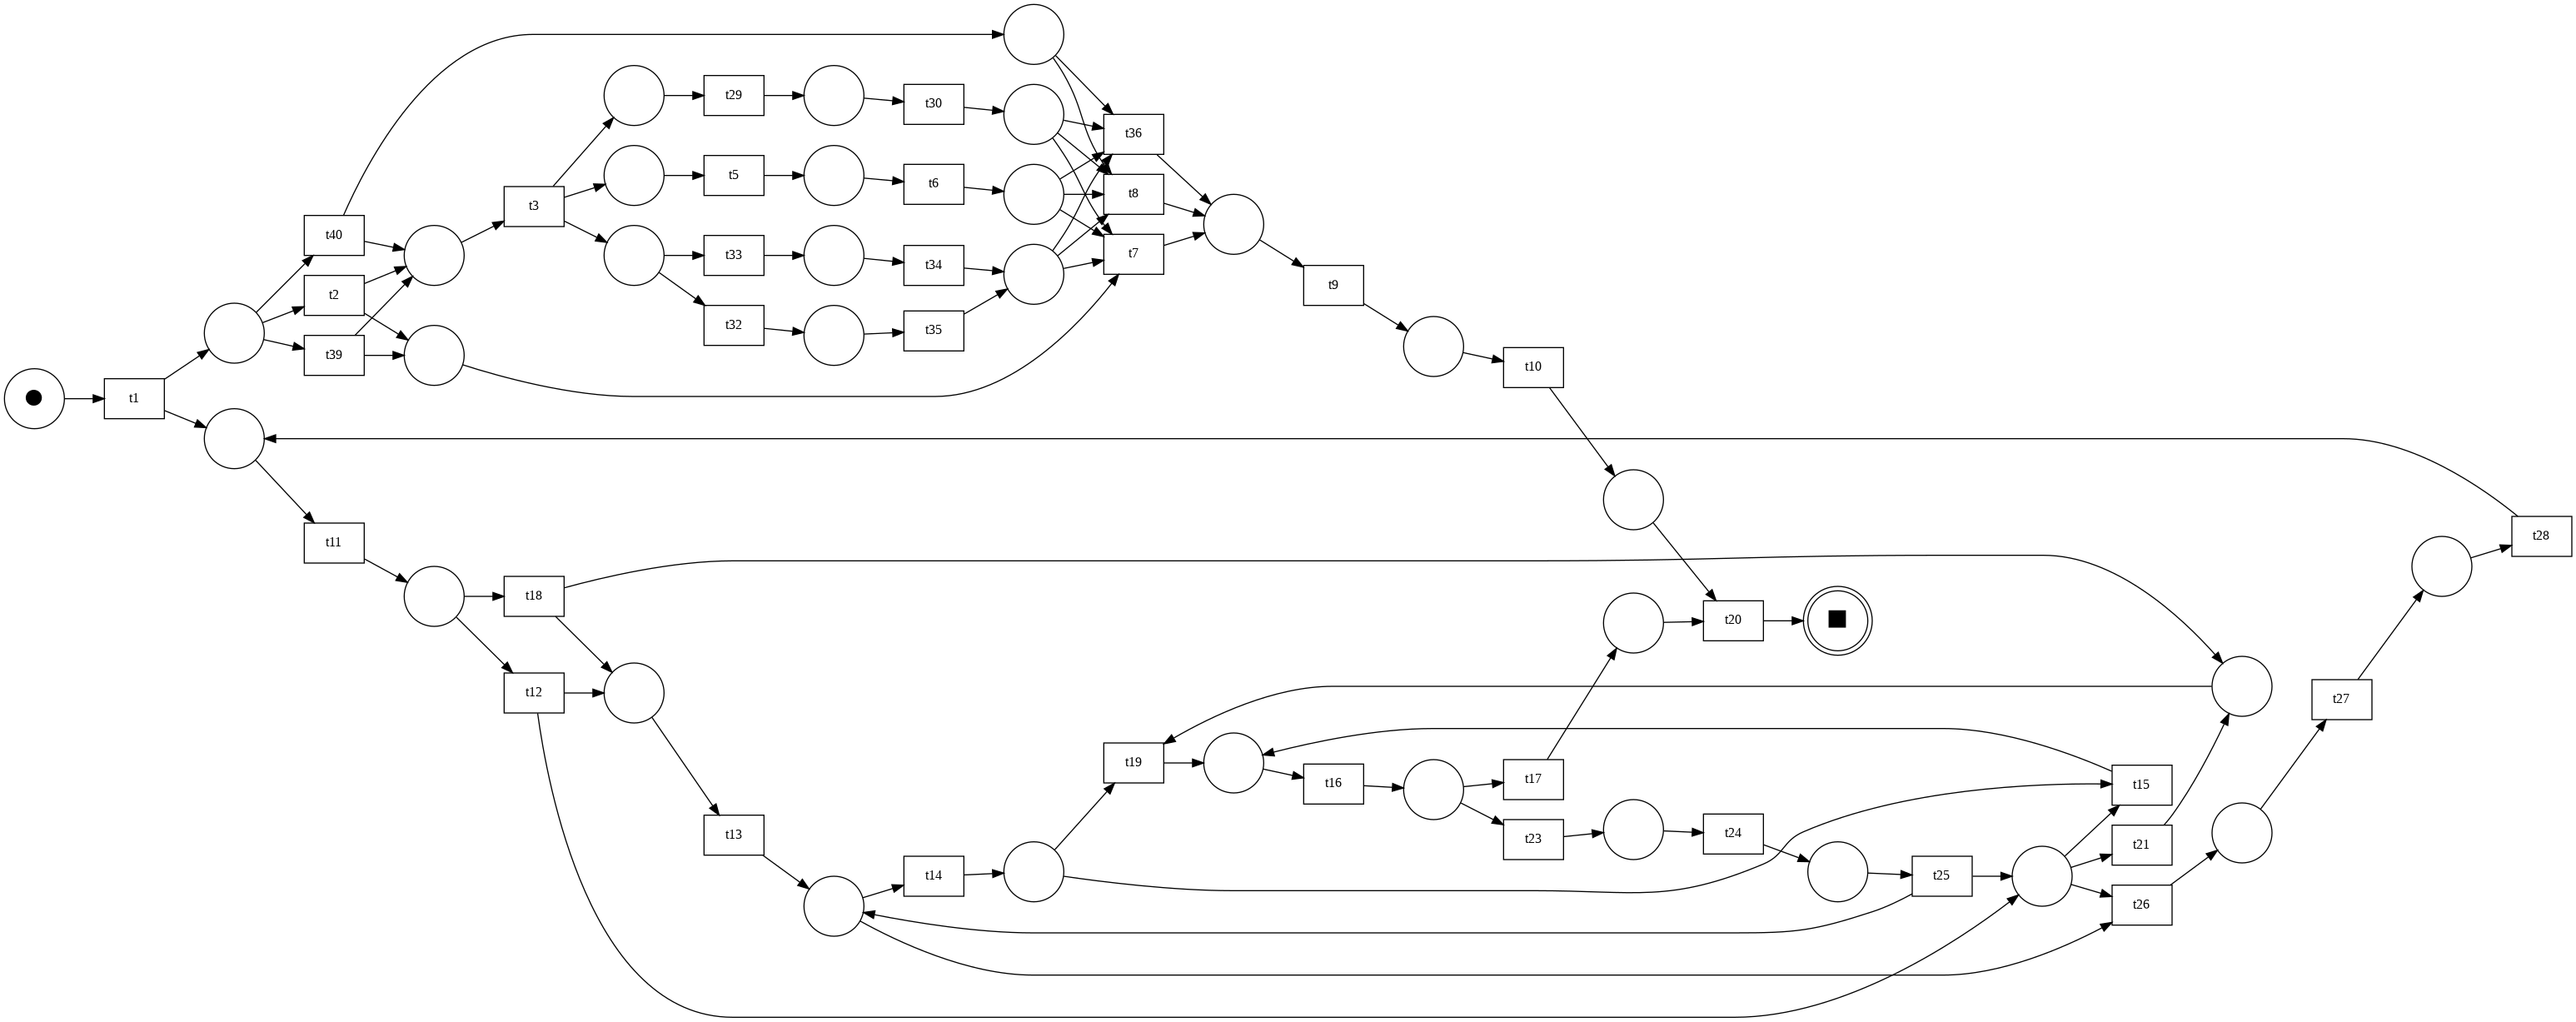

pdc2023_110010.pnml


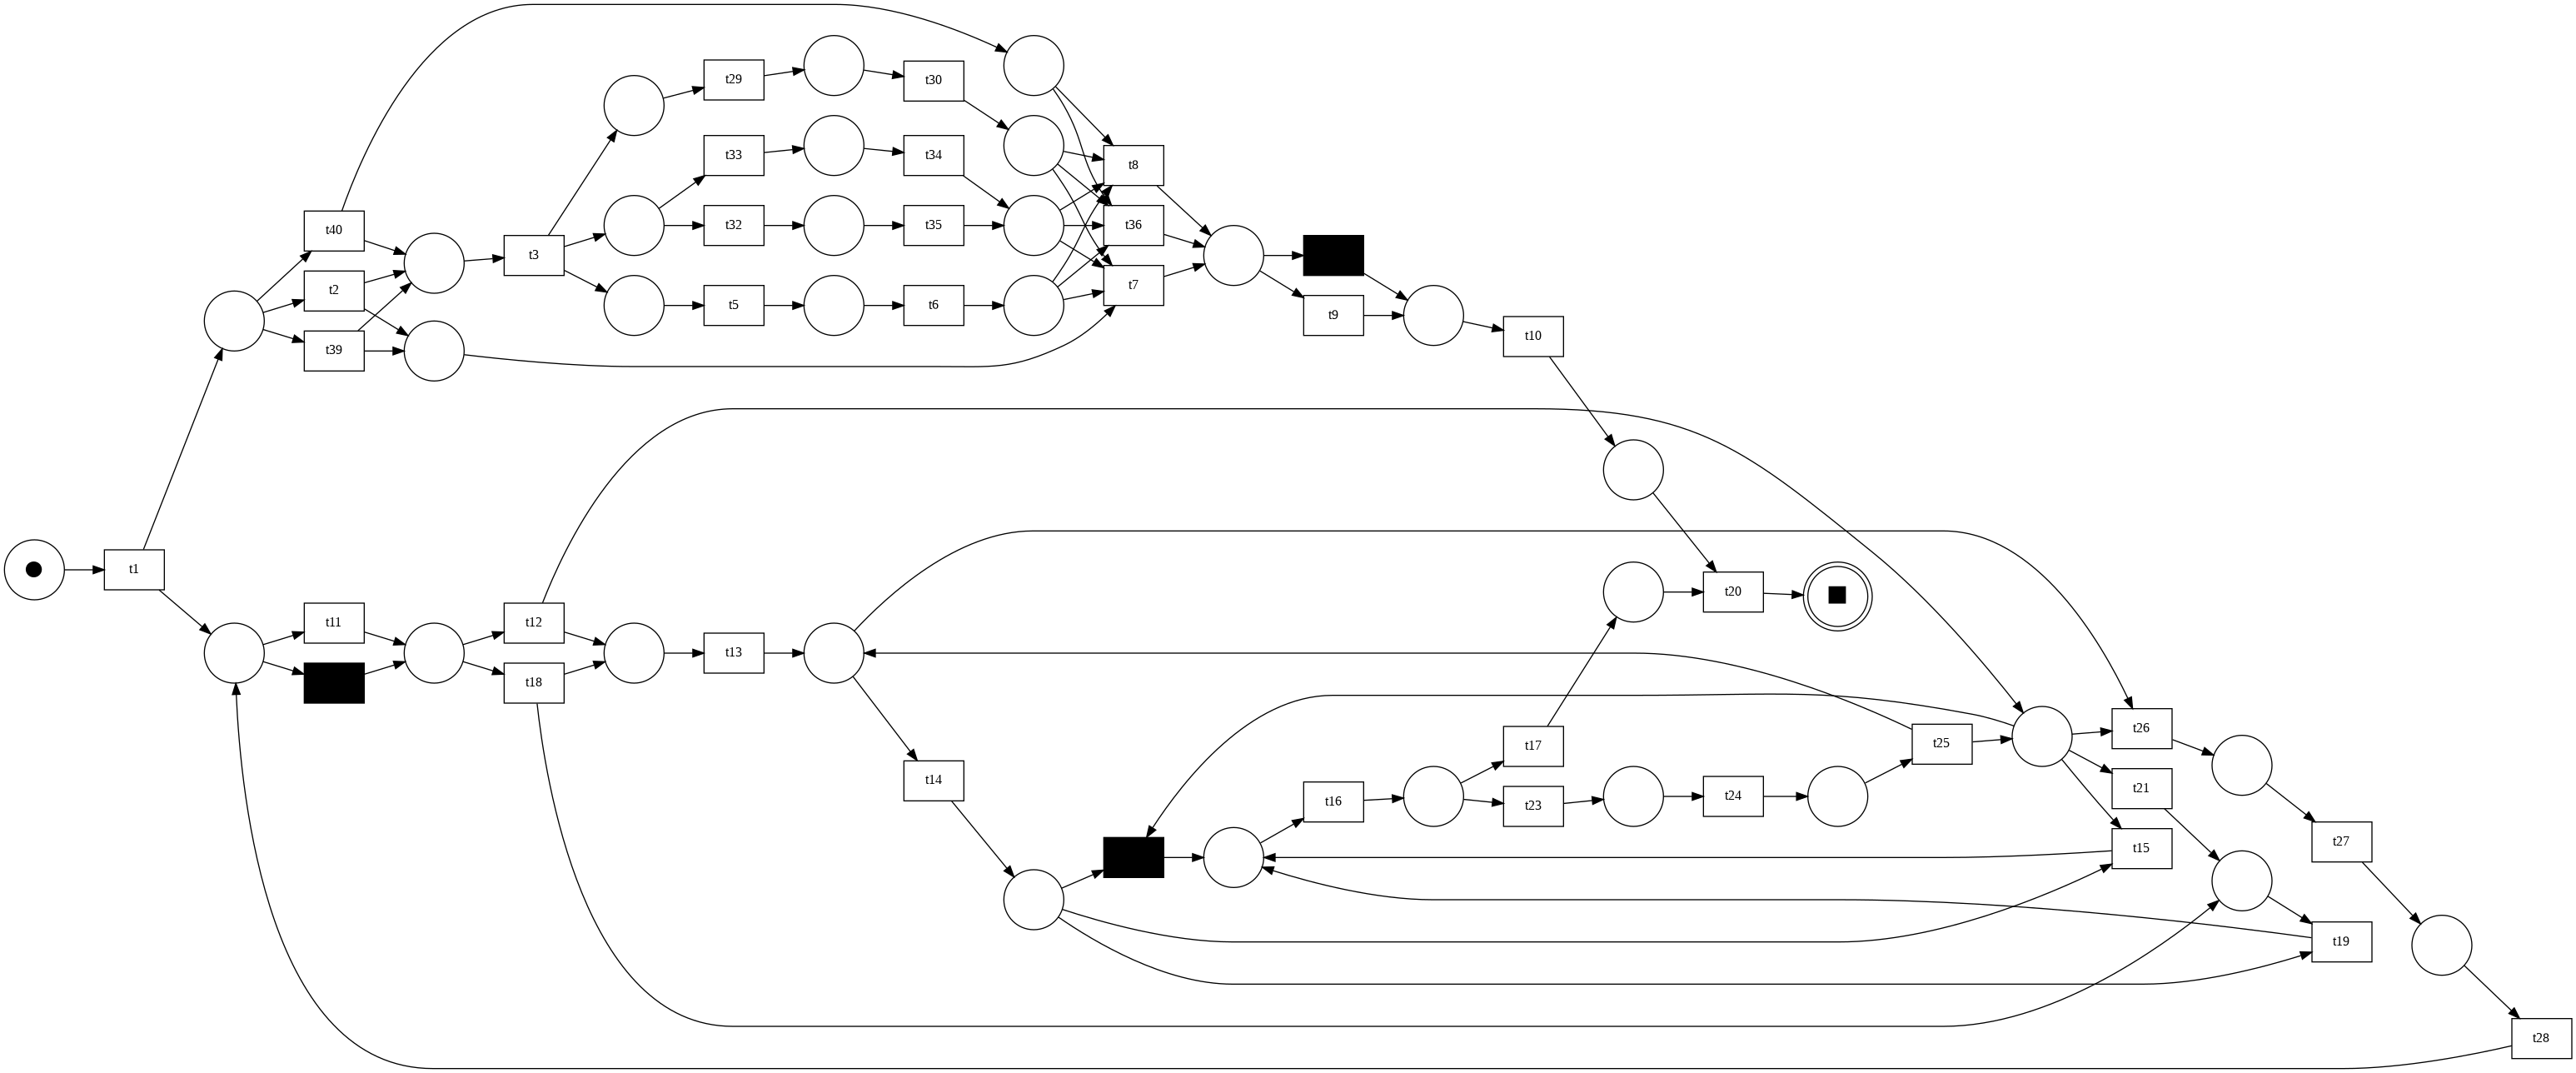

pdc2023_111000.pnml


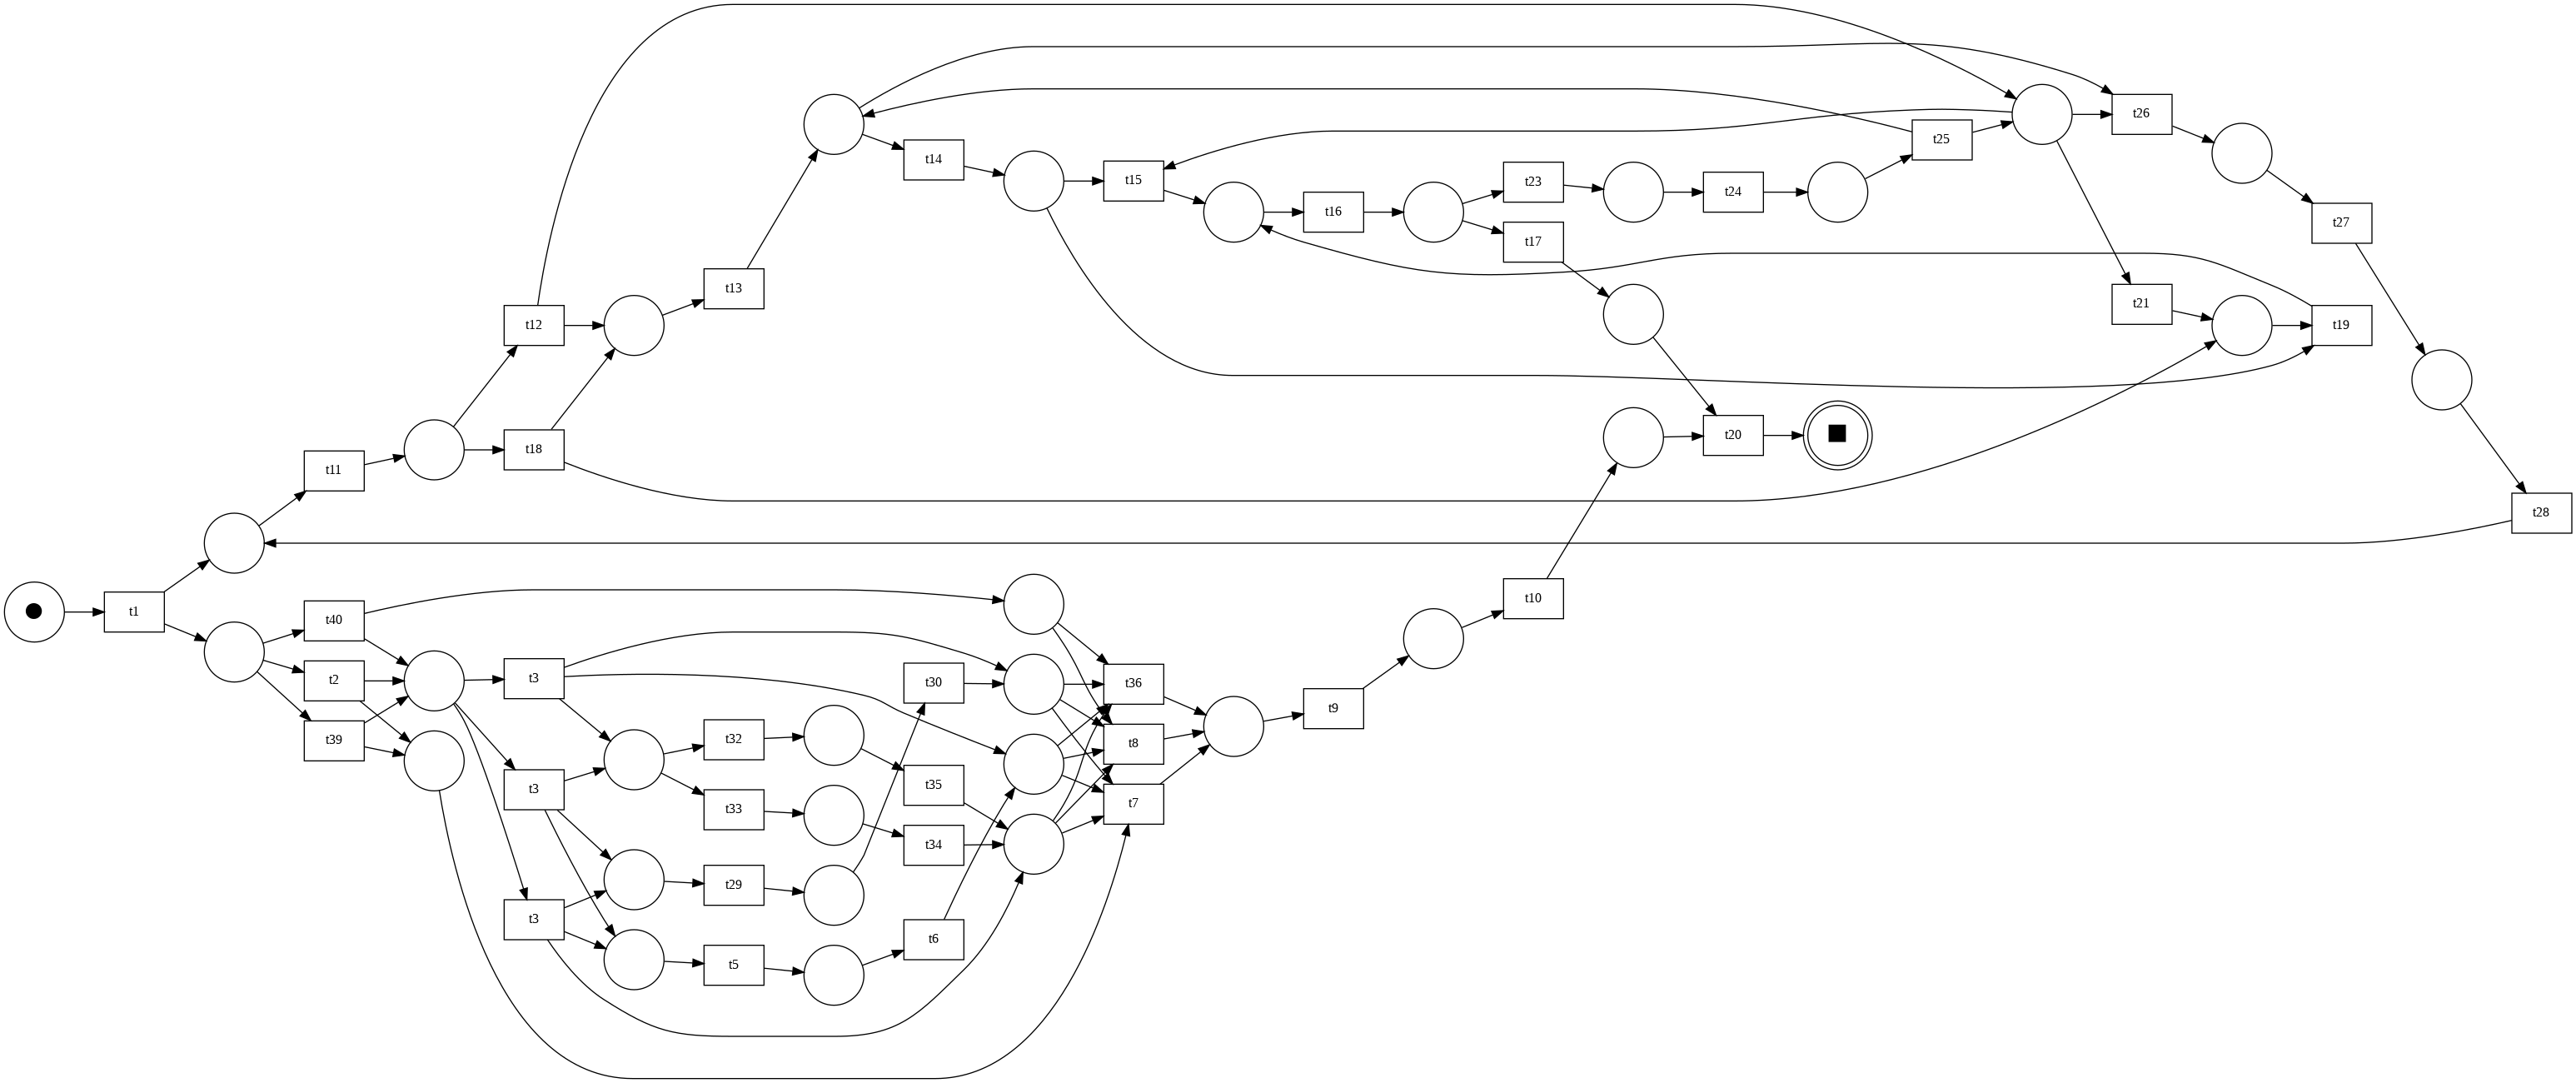

pdc2023_111010.pnml


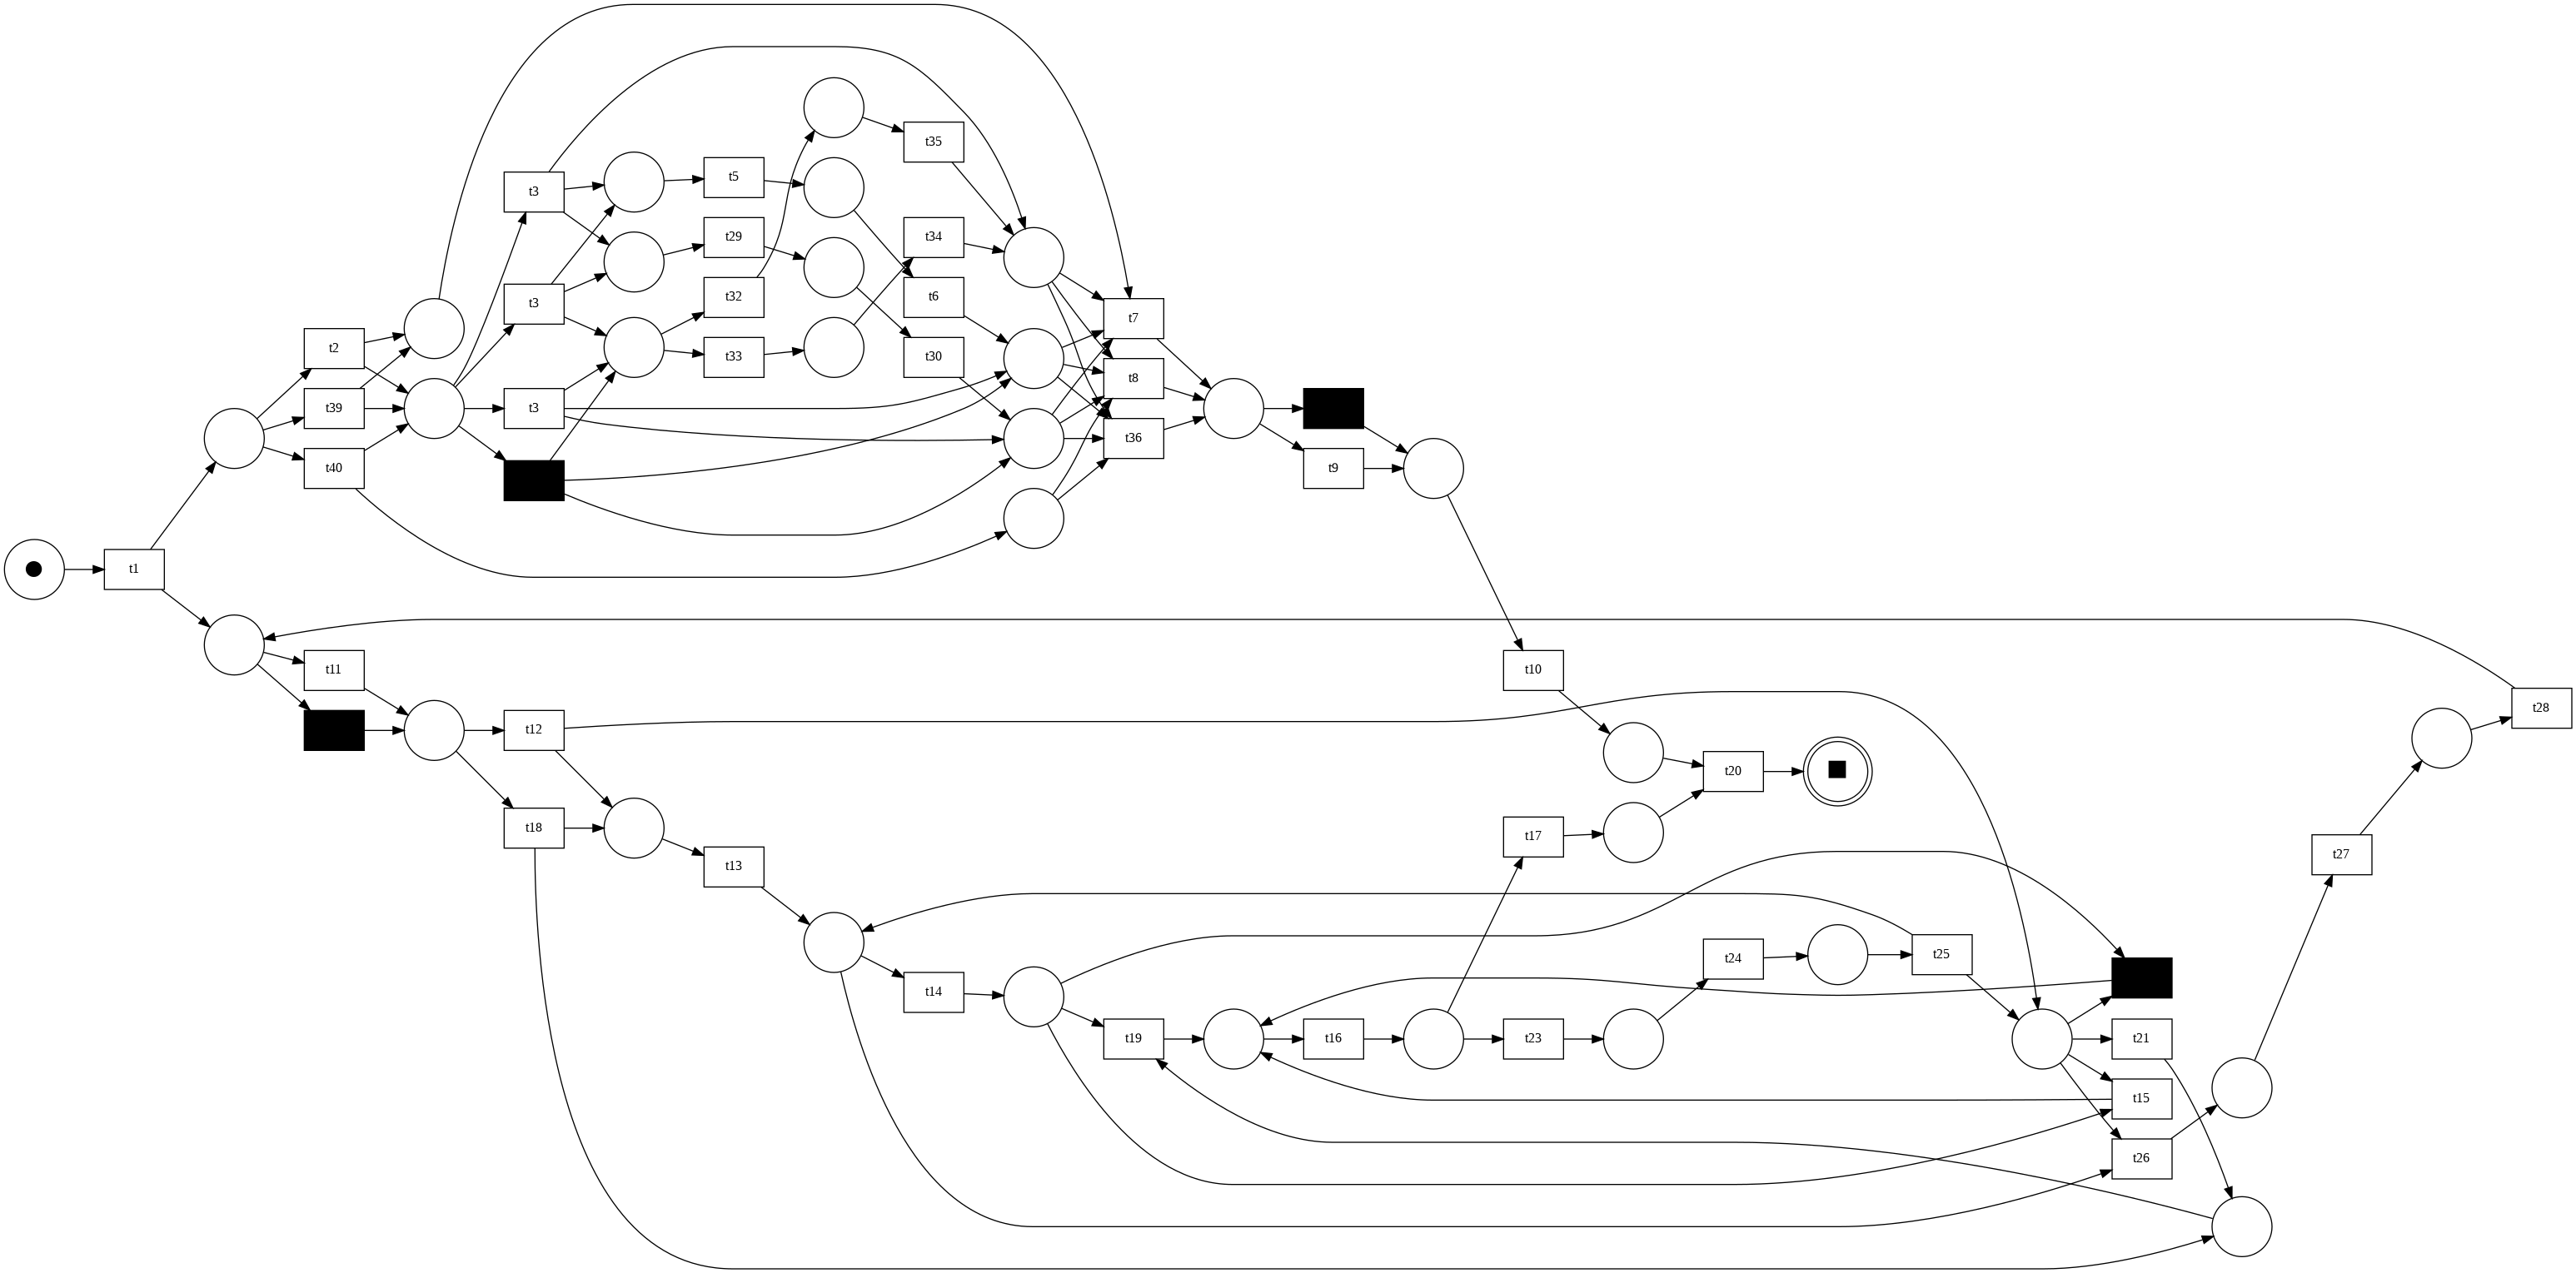

pdc2023_120000.pnml


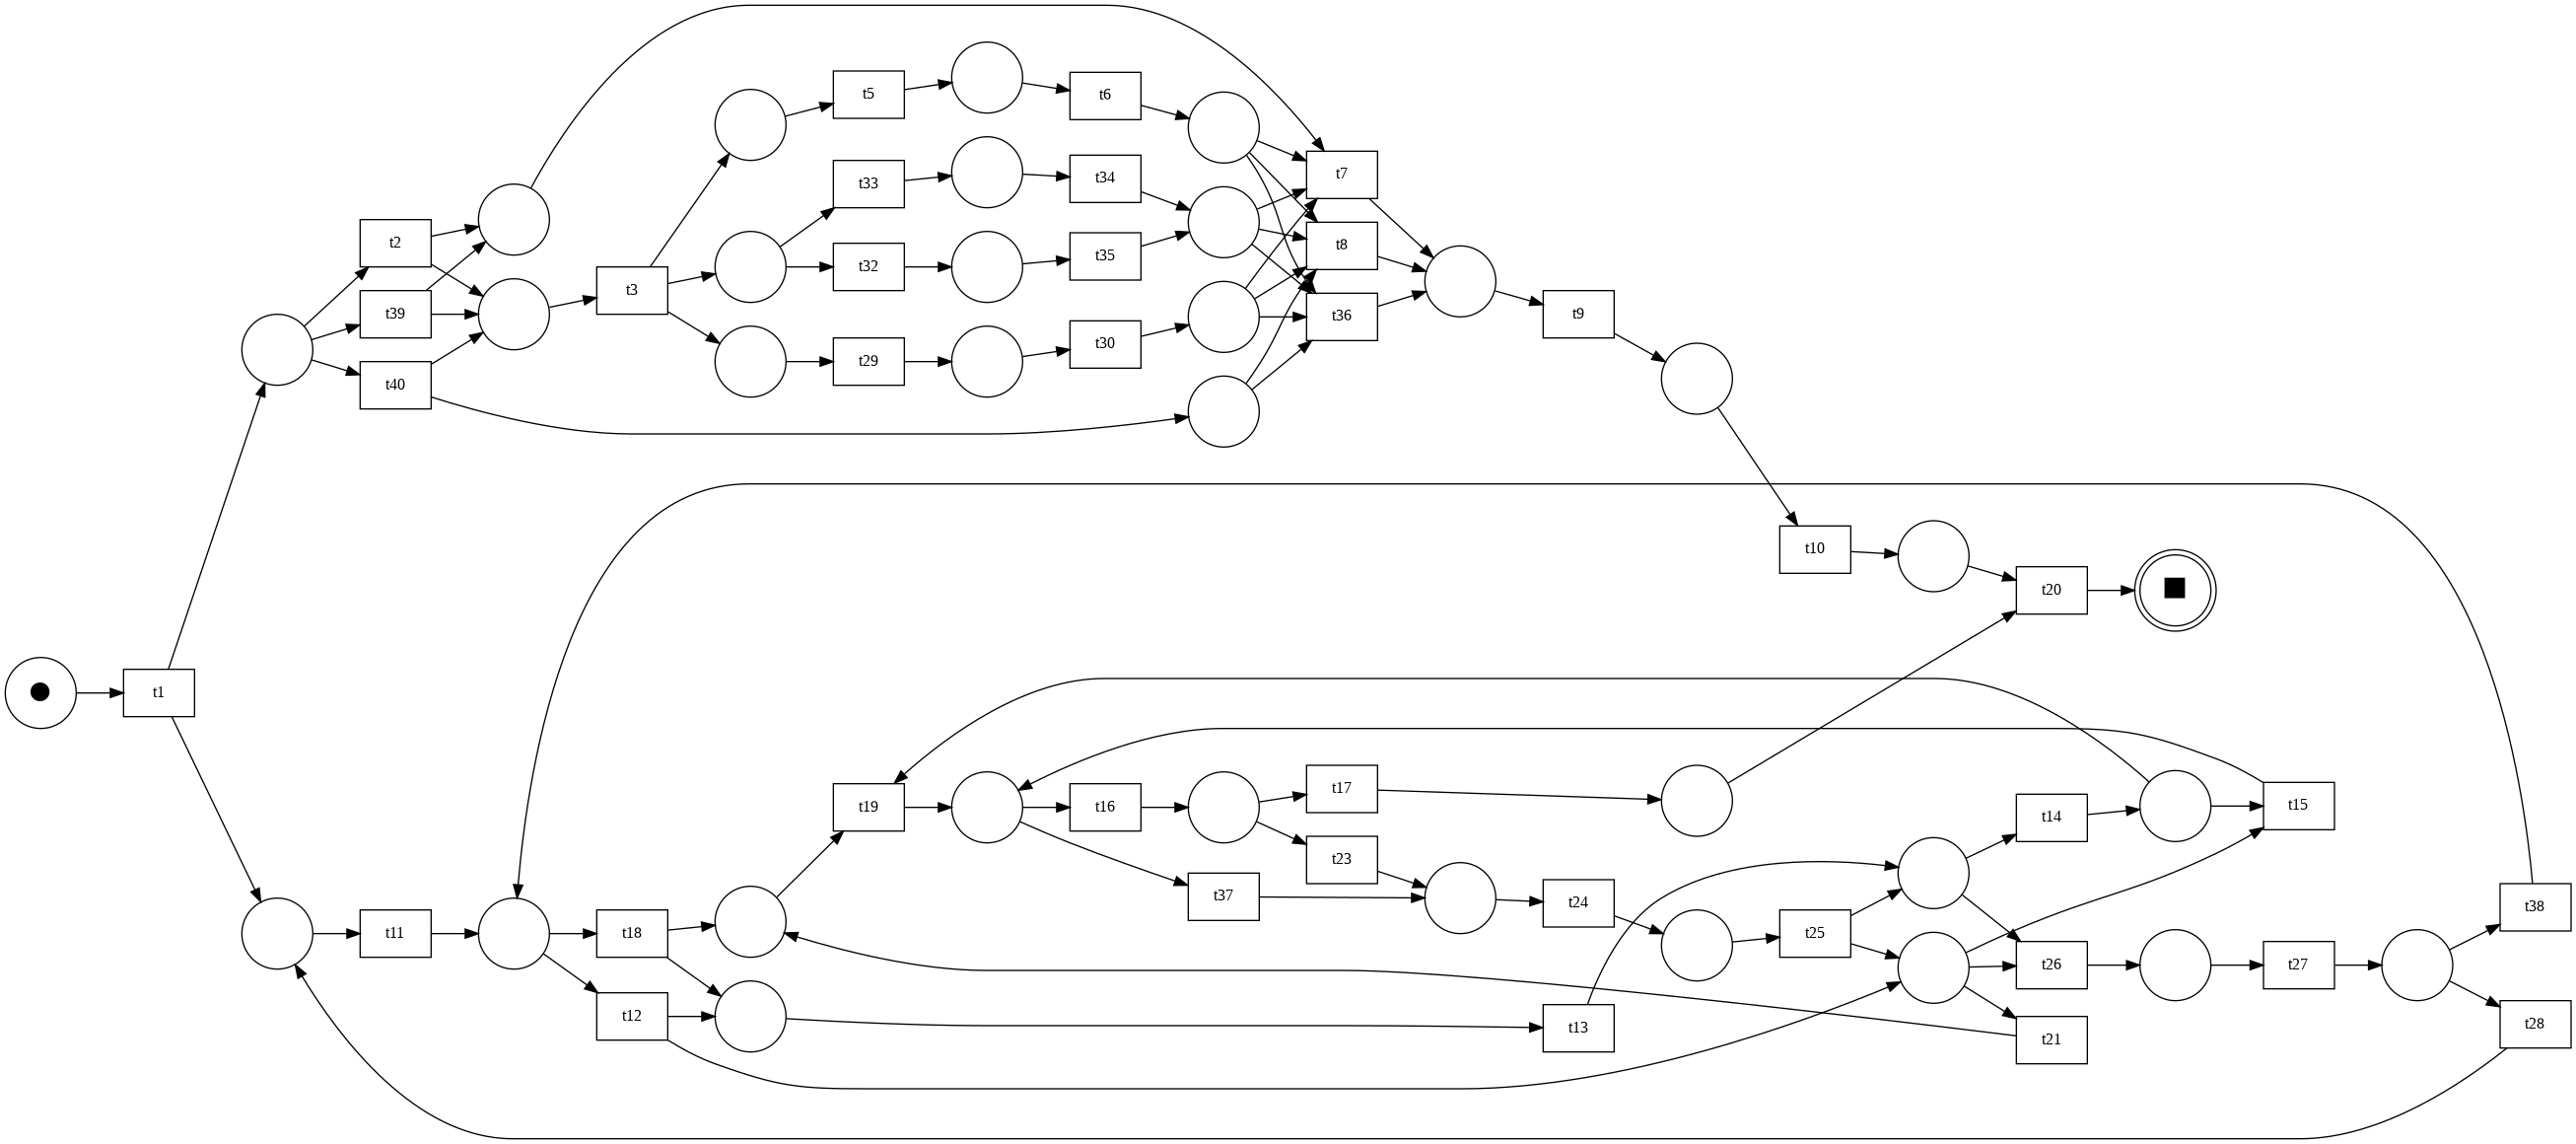

pdc2023_120010.pnml


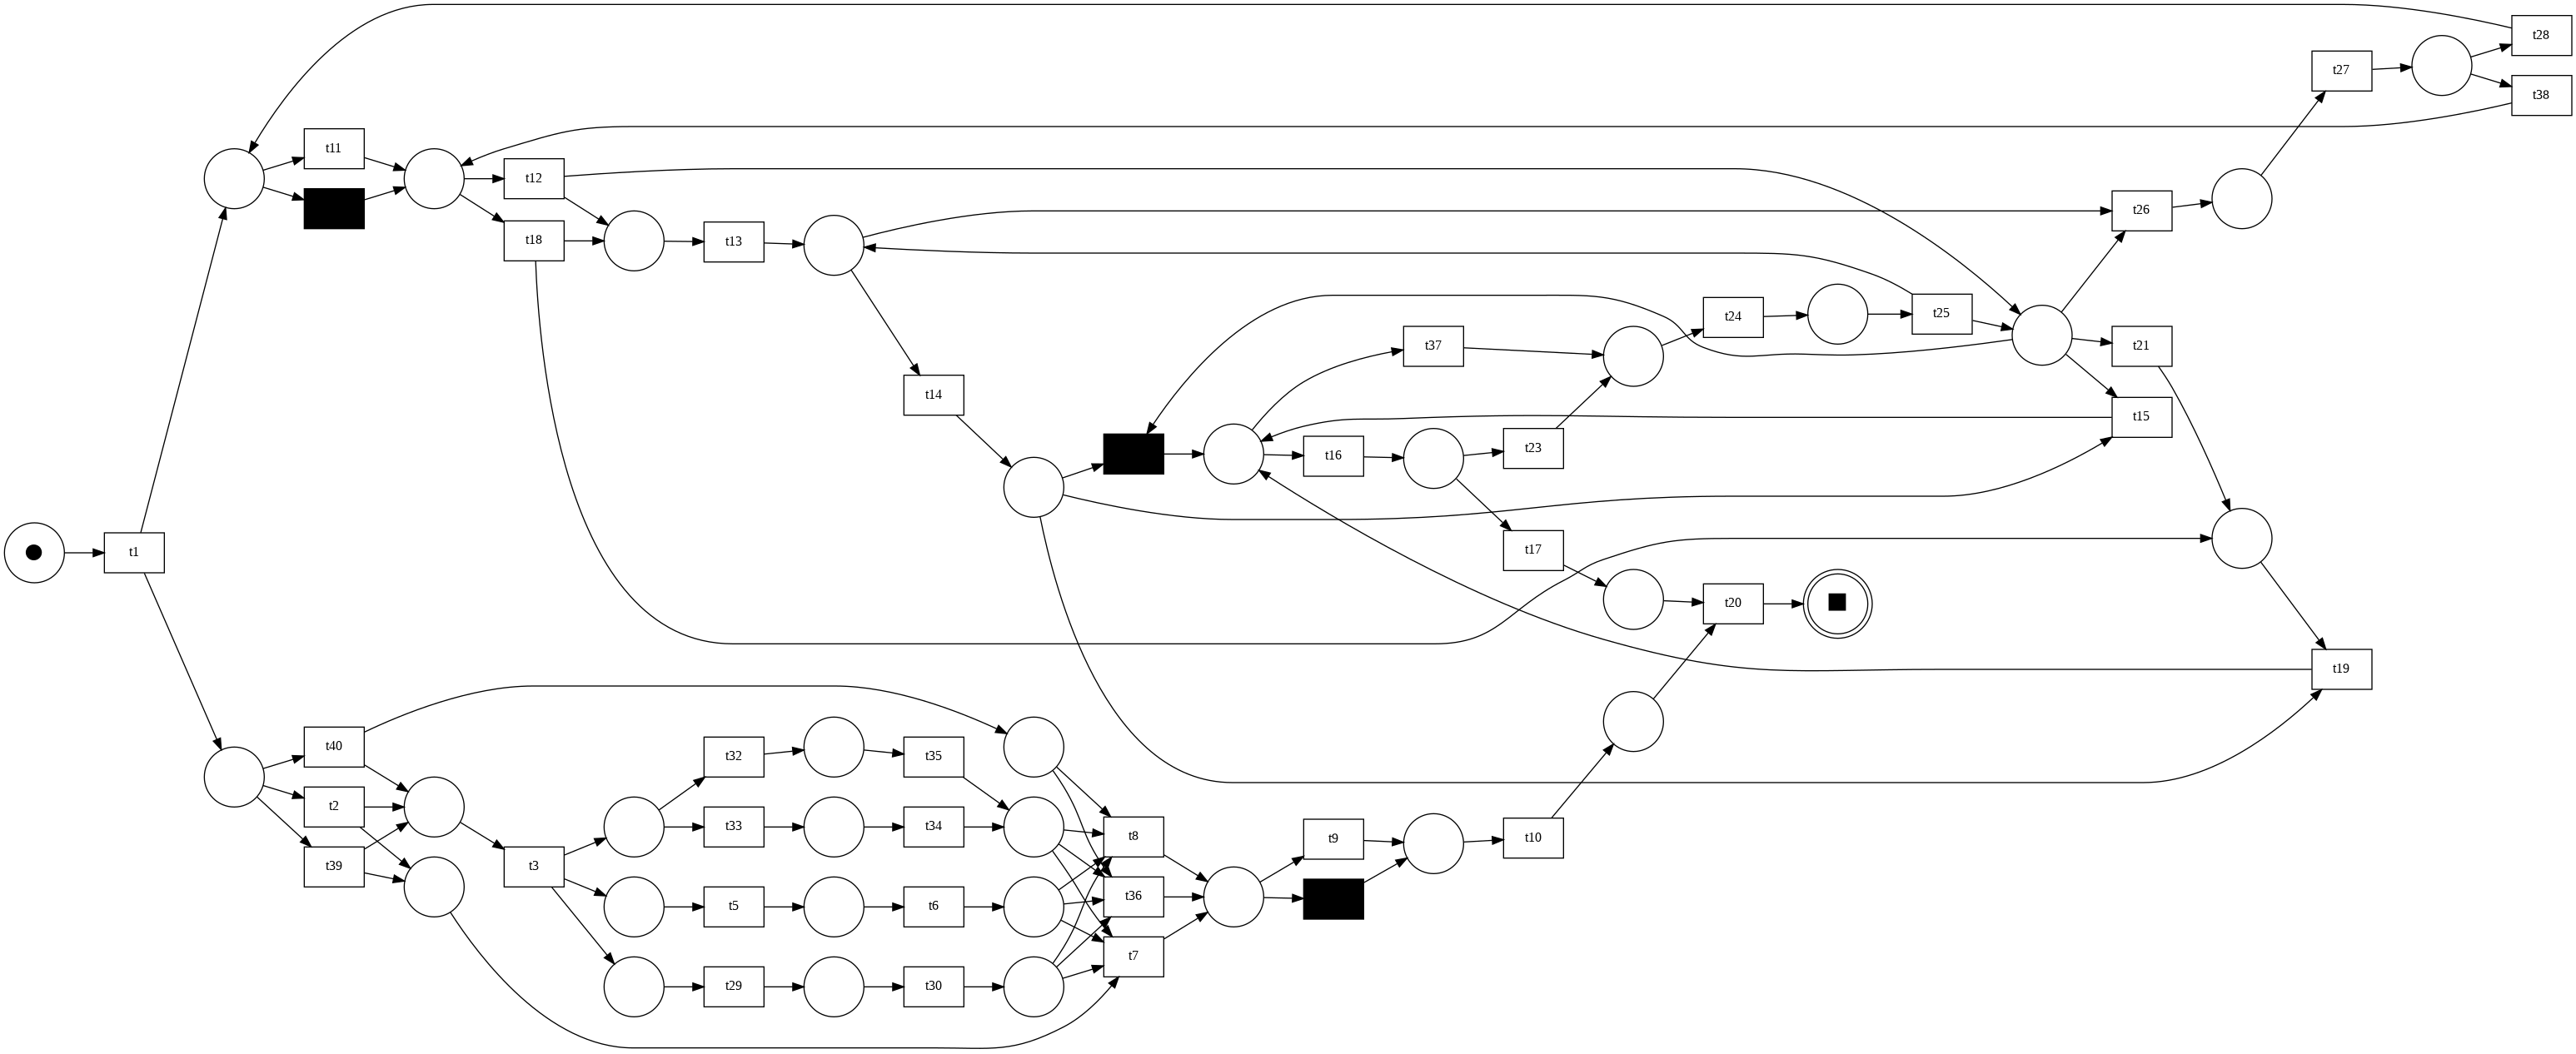

pdc2023_121000.pnml


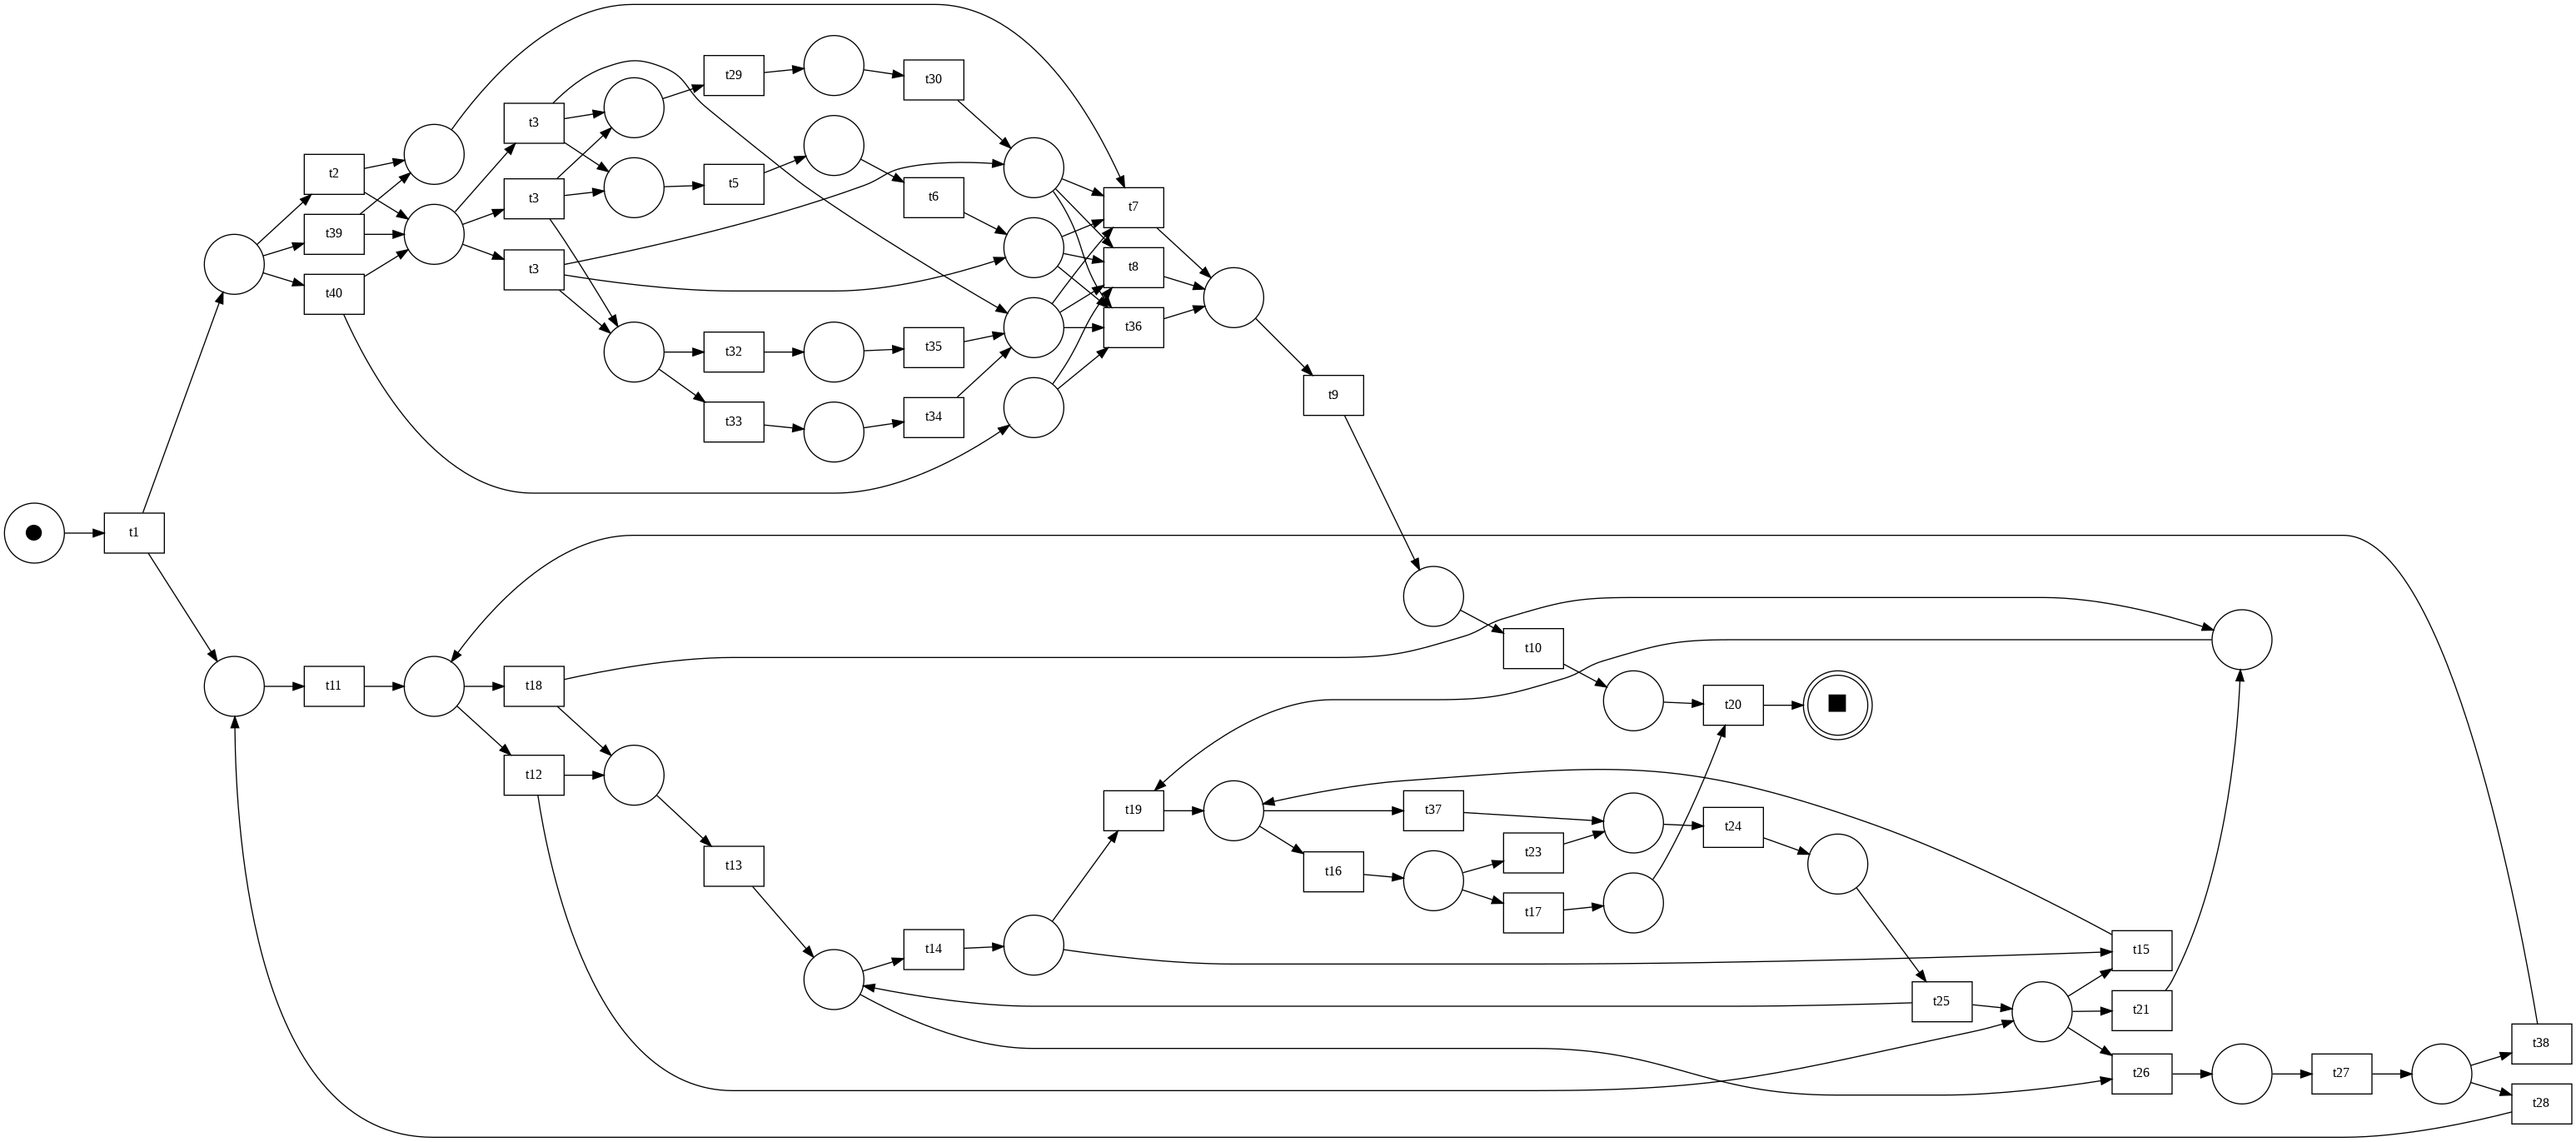

pdc2023_121010.pnml


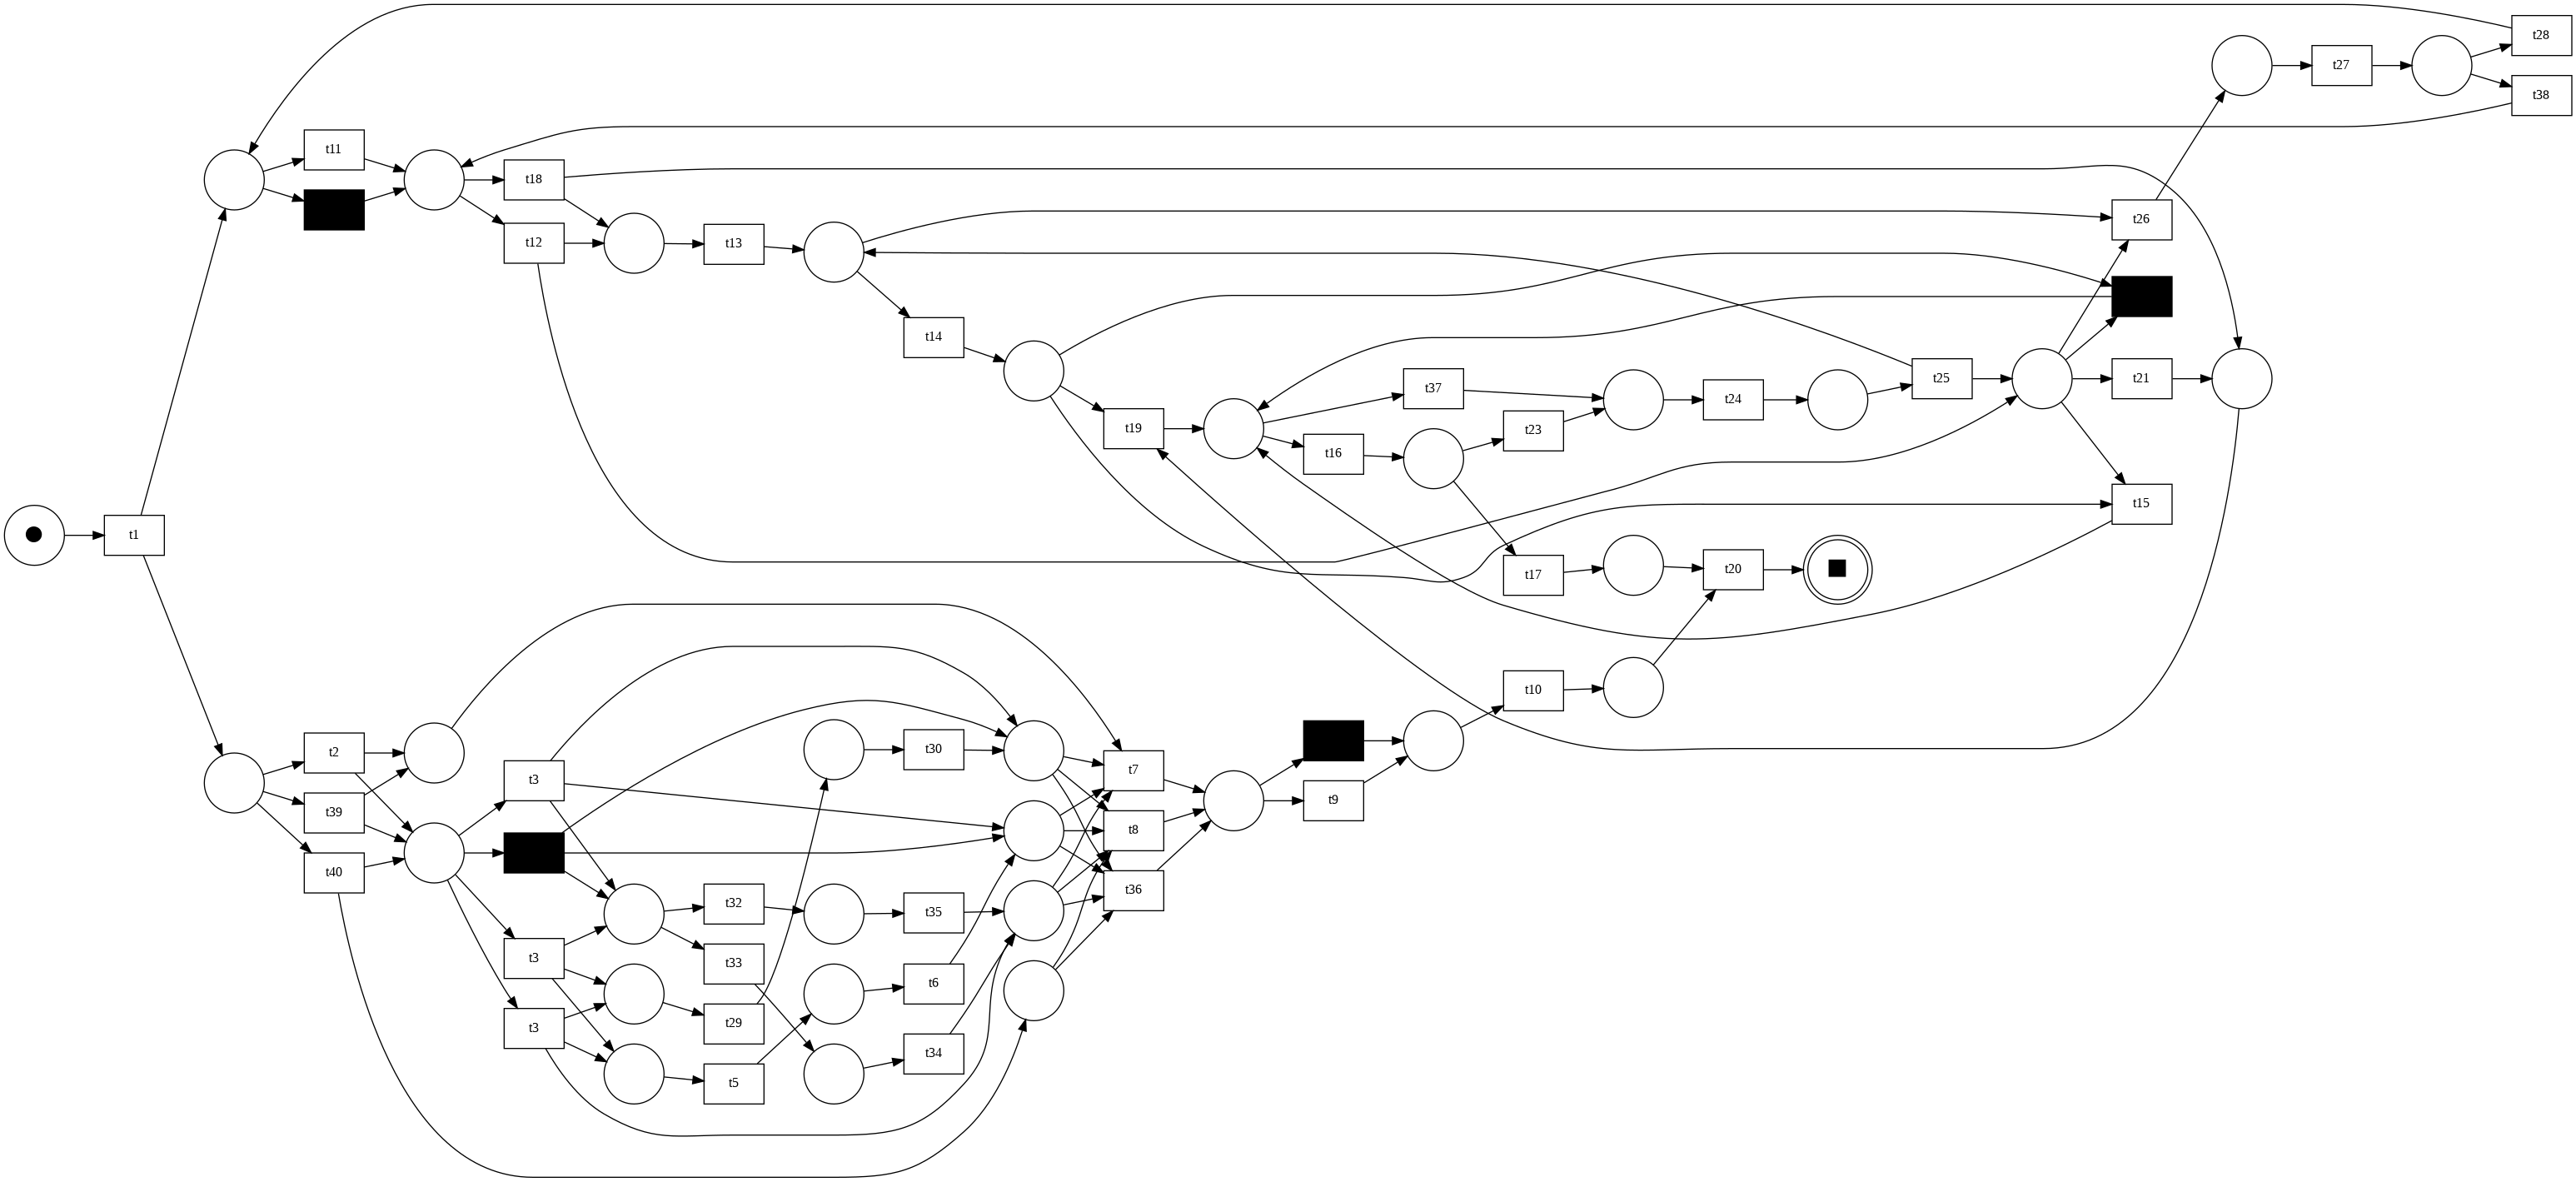

In [40]:
for member in clusters_members['1']:
    print(member)
    net, im, fm = pm4py.read_pnml(os.path.join('./Models/', member))
    pm4py.view_petri_net(net, im, fm)